# Imports

In [165]:
# Standard library
import re
import random
import os
import warnings
from collections import Counter

# Core scientific
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP — NLTK
import nltk
from nltk import pos_tag, word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# HuggingFace
from huggingface_hub import login
from datasets import load_dataset

# Gensim
import gensim
import gensim.downloader as api

# scikit-learn
from sklearn.feature_extraction.text import (
    CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Keras / TensorFlow
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Visualisation extras
from matplotlib.lines import Line2D
from wordcloud import WordCloud
from adjustText import adjust_text


warnings.filterwarnings('ignore')
nltk.download(['punkt_tab', 'averaged_perceptron_tagger_eng'], quiet=True)

# Shared colour palette
POS_COLOR, NEG_COLOR = 'steelblue', 'tomato'

# Central store for all model results — populated throughout the notebook
model_results = {}



In [ ]:
SEED = 3512
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Data Collection

In [3]:
# load token for huggingface
with open('tokens/token_hf.txt', 'r') as file:
    token = file.read()

# login on huggingface via token
login(token=token)

In [4]:
# Load the dataset
dataset = load_dataset("cornell-movie-review-data/rotten_tomatoes")

# Inspect the structure
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})


In [5]:
# Convert train-val-test split to a pandas DataFrame
df_train = pd.DataFrame(dataset['train'])
df_val = pd.DataFrame(dataset['validation'])
df_test = pd.DataFrame(dataset['test'])

print(df_train.shape, df_val.shape, df_test.shape)

(8530, 2) (1066, 2) (1066, 2)


In [6]:
# Check for null values
df_train.isnull().sum(), df_val.isnull().sum(), df_test.isnull().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

In [7]:
# Check for target proportions
(
    df_train['label'].value_counts() / df_train.shape[0],
    df_val['label'].value_counts() / df_val.shape[0],
    df_test['label'].value_counts() / df_test.shape[0],
)

(label
 1    0.5
 0    0.5
 Name: count, dtype: float64,
 label
 1    0.5
 0    0.5
 Name: count, dtype: float64,
 label
 1    0.5
 0    0.5
 Name: count, dtype: float64)

# Rule-based Analysis using regexes

## EDA

In [8]:
df = df_train.copy()

In [9]:
df.head()

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1


In [10]:
df['text'][399]

'chalk it up to my adoration for both de niro and murphy , but i had a pretty good time with this movie - despite its myriad flaws .'

### Data Overview

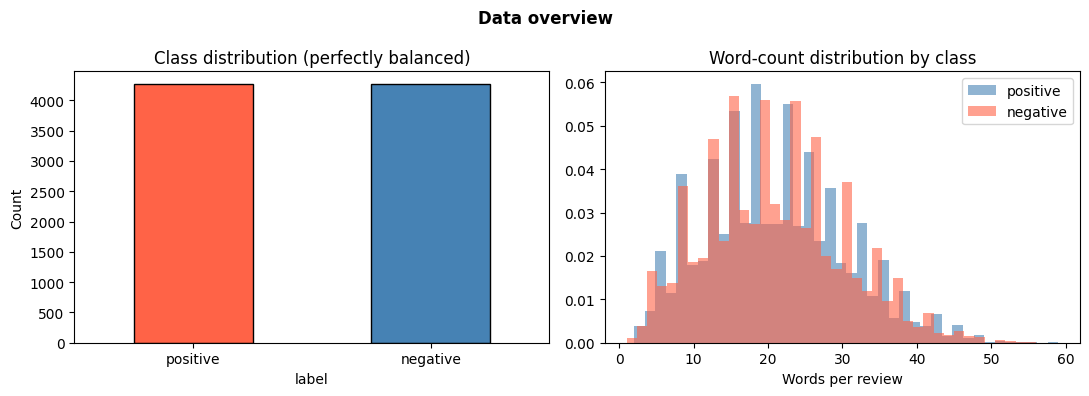

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Class balance
df['label'].value_counts().rename({0: 'negative', 1: 'positive'}).plot(
    kind='bar', ax=axes[0], color=[NEG_COLOR, POS_COLOR], edgecolor='black')
axes[0].set_title('Class distribution (perfectly balanced)')
axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)

# Word-count distribution — are longer reviews more positive?
df['word_count'] = df['text'].str.split().str.len()
for label, color, name in [(1, POS_COLOR, 'positive'), (0, NEG_COLOR, 'negative')]:
    axes[1].hist(df[df['label'] == label]['word_count'],
                 bins=40, alpha=0.6, color=color, label=name, density=True)
axes[1].set_title('Word-count distribution by class')
axes[1].set_xlabel('Words per review'); axes[1].legend()

plt.suptitle('Data overview', fontweight='bold'); plt.tight_layout(); plt.show()

label           0    1
len_bin               
(0.942, 3.9]   29   23
(3.9, 6.8]    173  173
(6.8, 9.7]    293  305
(9.7, 12.6]   366  358
(12.6, 15.5]  439  439
(15.5, 18.4]  505  503
(18.4, 21.3]  516  519
(21.3, 24.2]  493  498
(24.2, 27.1]  433  409
(27.1, 30.0]  330  329
(30.0, 32.9]  190  193
(32.9, 35.8]  198  200
(35.8, 38.7]  145  133
(38.7, 41.6]   75   82
(41.6, 44.5]   39   50
(44.5, 47.4]   25   32
(47.4, 50.3]    8   12
(50.3, 53.2]    6    4
(53.2, 56.1]    2    2
(56.1, 59.0]    0    1


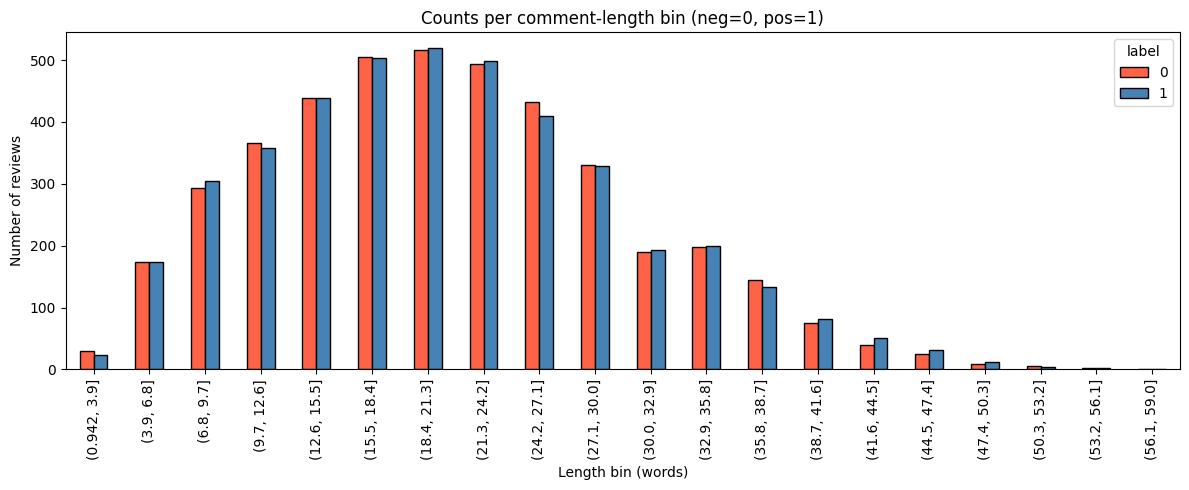

In [12]:
# Length bins: divide comment length (word count) into 20 bins and compare label counts
lengths = df['text'].str.split().str.len()
len_bins = pd.cut(lengths, bins=20)
counts = df.assign(len_bin=len_bins).groupby(['len_bin', 'label']).size().unstack(fill_value=0)

print(counts)

# Quick stacked bar plot (negative=0, positive=1)
ax = counts.plot(kind='bar', stacked=False, figsize=(12,5), color=[NEG_COLOR, POS_COLOR], edgecolor='black')
ax.set_title('Counts per comment-length bin (neg=0, pos=1)')
ax.set_xlabel('Length bin (words)')
ax.set_ylabel('Number of reviews')
plt.tight_layout()
plt.show()


50/50 split, near-identical mean word count (~21 words).
Length alone carries no signal, we must look at the *words themselves*.

### Vocabulary Comparison via Word Clouds

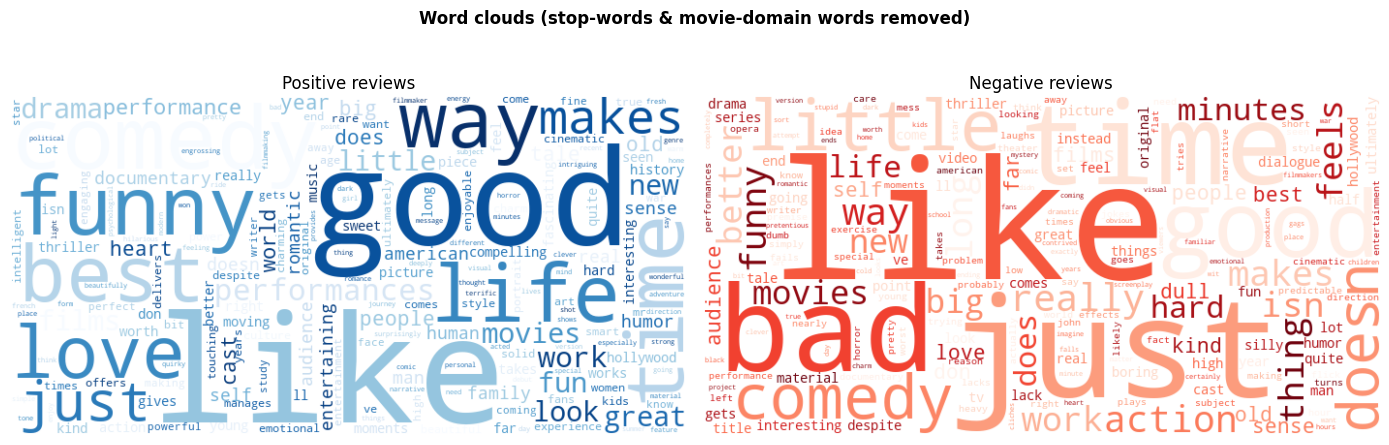

In [ ]:
MOVIE_STOPS = ['movie', 'film', 'story', 'plot', 'character', 'characters',
               'director', 'actor', 'actors', 'acting', 'script', 'scene',
               'scenes', 'watch', 'watching', 'cinema', 'screen', 'make']
ALL_STOPS = list(ENGLISH_STOP_WORDS.union(MOVIE_STOPS))

def class_word_freq(corpus, stop_words=ALL_STOPS, min_df=5, max_df=0.8):
    vec = CountVectorizer(stop_words=stop_words, min_df=min_df, max_df=max_df)
    X   = vec.fit_transform(corpus)
    freq = X.sum(axis=0).A1
    return dict(zip(vec.get_feature_names_out(), freq))

pos_freq = class_word_freq(df[df['label'] == 1]['text'])
neg_freq = class_word_freq(df[df['label'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, freq, cmap, title in [
        (axes[0], pos_freq, 'Blues',  'Positive reviews'),
        (axes[1], neg_freq, 'Reds',   'Negative reviews')]:
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(title)

plt.suptitle('Word clouds (stop-words & movie-domain words removed)',
             fontweight='bold'); plt.tight_layout(); plt.show()

The two word clouds are strikingly similar — high-frequency words like "good", "just", "like", "really", "comedy", "time" dominate both classes. The most common words in movie reviews are largely class-neutral. The meaningful signal is not in individual high-frequency words but in how they are used — "good" negated ("not good"), "time" in a phrase ("waste of time"), or "really" as a hedger ("not really funny"). This directly motivates moving beyond unigram frequency toward multi-word patterns, negation scope, and idioms.

Bigram word clouds can probably better show the divergence between classes.

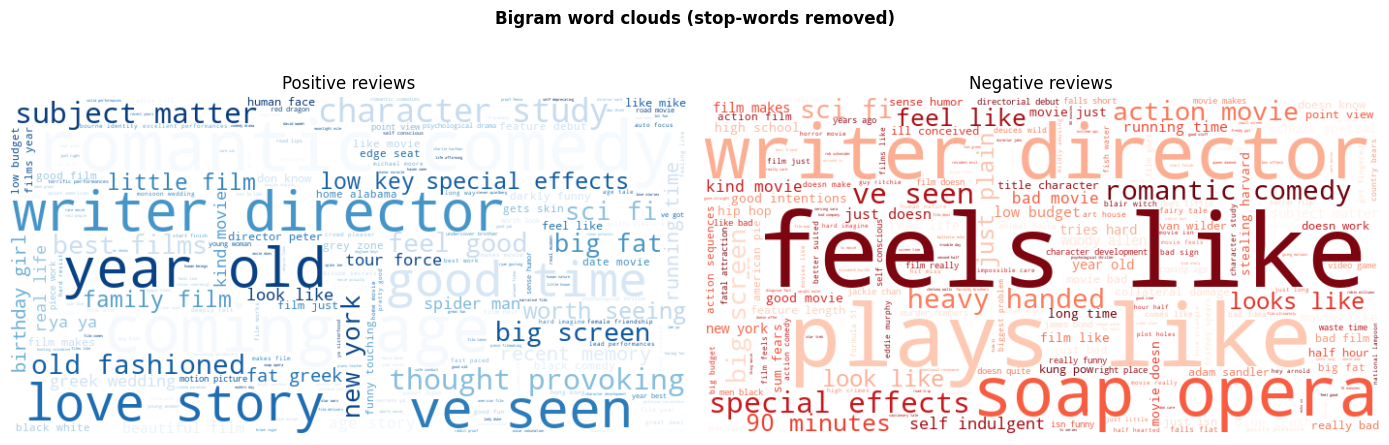

In [14]:
# Bigram word clouds
def class_bigram_freq(corpus, stop_words=list(ENGLISH_STOP_WORDS), min_df=3, max_df=0.8):
    vec = CountVectorizer(stop_words=stop_words, min_df=min_df, max_df=max_df,
                          ngram_range=(2, 2))
    X   = vec.fit_transform(corpus)
    freq = X.sum(axis=0).A1
    return dict(zip(vec.get_feature_names_out(), freq))

pos_bigram_freq = class_bigram_freq(df[df['label'] == 1]['text'])
neg_bigram_freq = class_bigram_freq(df[df['label'] == 0]['text'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, freq, cmap, title in [
        (axes[0], pos_bigram_freq, 'Blues', 'Positive reviews'),
        (axes[1], neg_bigram_freq, 'Reds',  'Negative reviews')]:
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap).generate_from_frequencies(freq)
    ax.imshow(wc, interpolation='bilinear'); ax.axis('off'); ax.set_title(title)

plt.suptitle('Bigram word clouds (stop-words removed)',
             fontweight='bold')
plt.tight_layout(); plt.show()

Bigrams reveal what unigrams obscured. Positive reviews use genre-affirming and experience phrases — "romantic comedy", "coming of age", "character study", "thought provoking" — signalling genuine engagement. Negative reviews cluster around comparison phrases ("feels like", "plays like", "film like") indicating the film feels derivative, alongside quality signals: "soap opera", "heavy handed", "self indulgent".

### Loyal Words Analysis

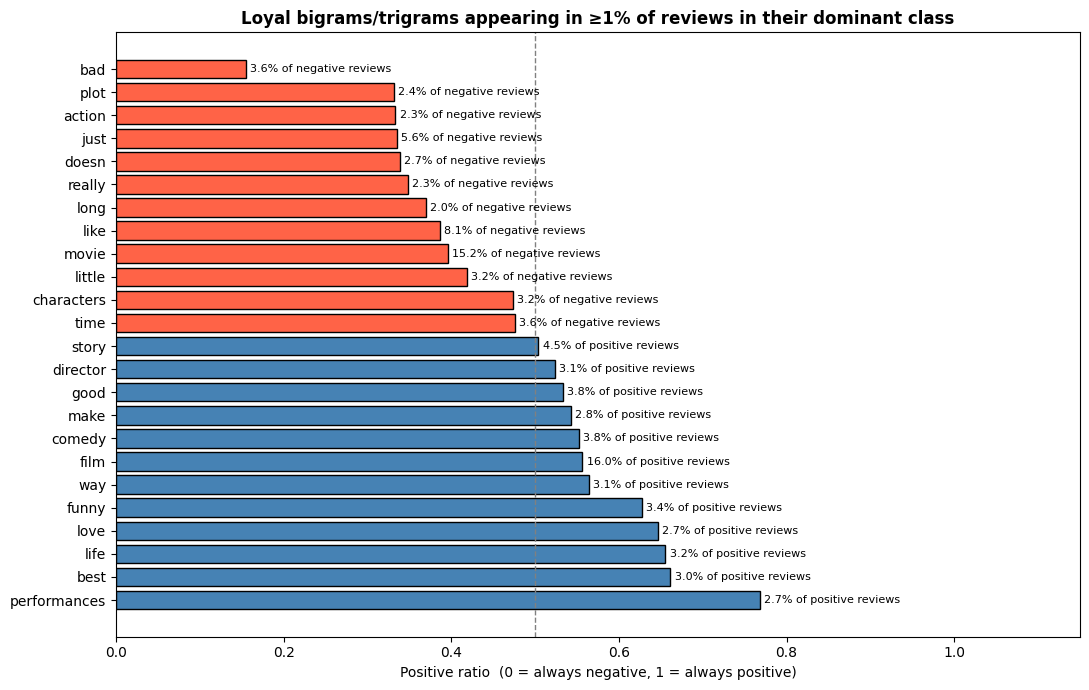

In [15]:
# Bigram/trigram loyalty — same vectorised approach, ngram_range=(2,3)
def auto_loyal_ngrams(df, min_class_freq=0.01, top_n=15,
                      pos_threshold=0.5, neg_threshold=0.5,
                      ngram_range=(1, 4)):

    pos_texts = df[df['label']==1]['text']
    neg_texts = df[df['label']==0]['text']
    n_pos, n_neg = len(pos_texts), len(neg_texts)

    vec     = CountVectorizer(stop_words='english', min_df=3, max_df=0.9,
                              binary=True, ngram_range=ngram_range)
    pos_mat = vec.fit_transform(pos_texts)
    neg_mat = vec.transform(neg_texts)
    vocab   = vec.get_feature_names_out()

    p_counts = np.asarray(pos_mat.sum(axis=0)).flatten()
    n_counts = np.asarray(neg_mat.sum(axis=0)).flatten()
    totals   = p_counts + n_counts

    pos_ratio = np.divide(p_counts, totals, where=totals>0,
                          out=np.zeros_like(p_counts, dtype=float))

    result = pd.DataFrame({
        'ngram':     vocab,
        'pos_ratio': pos_ratio,
        'pos_freq':  p_counts / n_pos,
        'neg_freq':  n_counts / n_neg,
        'total':     totals,
    })

    top_pos = (result[result['pos_ratio'] >= pos_threshold]
               .assign(sentiment='positive', class_freq=result['pos_freq'])
               .query('class_freq >= @min_class_freq')
               .nlargest(top_n, 'class_freq'))

    top_neg = (result[result['pos_ratio'] <= neg_threshold]
               .assign(sentiment='negative', class_freq=result['neg_freq'])
               .query('class_freq >= @min_class_freq')
               .nlargest(top_n, 'class_freq'))

    return pd.concat([top_pos, top_neg]).sort_values('pos_ratio', ascending=False)


ngram_loyalty = auto_loyal_ngrams(df, min_class_freq=0.01, top_n=12)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(ngram_loyalty['ngram'], ngram_loyalty['pos_ratio'],
        color=[POS_COLOR if s == 'positive' else NEG_COLOR
               for s in ngram_loyalty['sentiment']], edgecolor='black')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
for i, (_, row) in enumerate(ngram_loyalty.iterrows()):
    ax.text(row['pos_ratio'] + 0.005, i,
            f"{row['class_freq']:.1%} of {row['sentiment']} reviews",
            va='center', fontsize=8)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Positive ratio  (0 = always negative, 1 = always positive)')
ax.set_title('Loyal bigrams/trigrams appearing in ≥1% of reviews in their dominant class',
             fontweight='bold')
plt.tight_layout(); plt.show()

Even with relaxed thresholds, the most frequent class-skewed terms remain largely single words — confirming that individual words carry weak but real directional signal: "bad", "just", "doesn't" lean negative; "performances", "funny", "best", "love" lean positive. However, all pos_ratios sit between 0.1–0.8, far from the 0.0 or 1.0 we need for reliable rules.

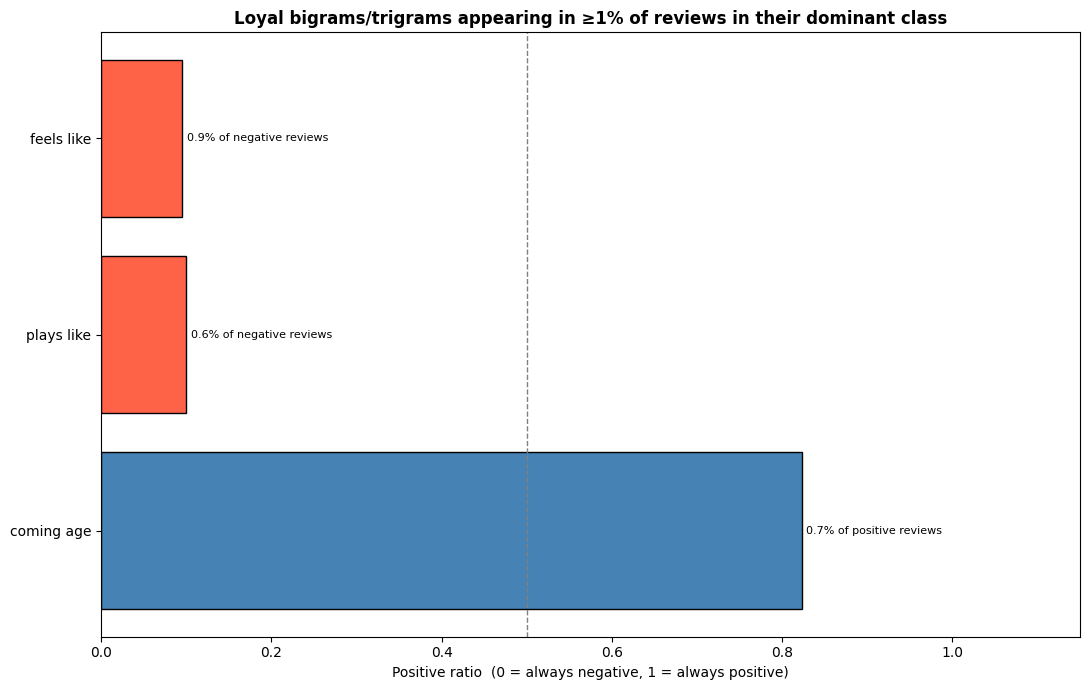

In [16]:
ngram_loyalty = auto_loyal_ngrams(
    df,
    min_class_freq=0.005,  # lower — bigrams are naturally rarer
    top_n=12,
    pos_threshold=0.75,    # stricter loyalty
    neg_threshold=0.25,
    ngram_range=(2, 3)     # exclude unigrams
)


fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(ngram_loyalty['ngram'], ngram_loyalty['pos_ratio'],
        color=[POS_COLOR if s == 'positive' else NEG_COLOR
               for s in ngram_loyalty['sentiment']], edgecolor='black')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
for i, (_, row) in enumerate(ngram_loyalty.iterrows()):
    ax.text(row['pos_ratio'] + 0.005, i,
            f"{row['class_freq']:.1%} of {row['sentiment']} reviews",
            va='center', fontsize=8)
ax.set_xlim(0, 1.15)
ax.set_xlabel('Positive ratio  (0 = always negative, 1 = always positive)')
ax.set_title('Loyal bigrams/trigrams appearing in ≥1% of reviews in their dominant class',
             fontweight='bold')
plt.tight_layout(); plt.show()

Only three bigrams survive strict loyalty filtering. "feels like" and "plays like" (both visible as dominant terms in the negative bigram cloud) are almost exclusively negative (pos_ratio ≈ 0.1), capturing the classic critic pattern of comparing a film unfavourably to something else. "coming of age" is the only reliably positive bigram. However, all three appear in under 1% of their dominant class — so while they are high-precision signals worth including in regex rules, they will only fire on a small fraction of reviews.

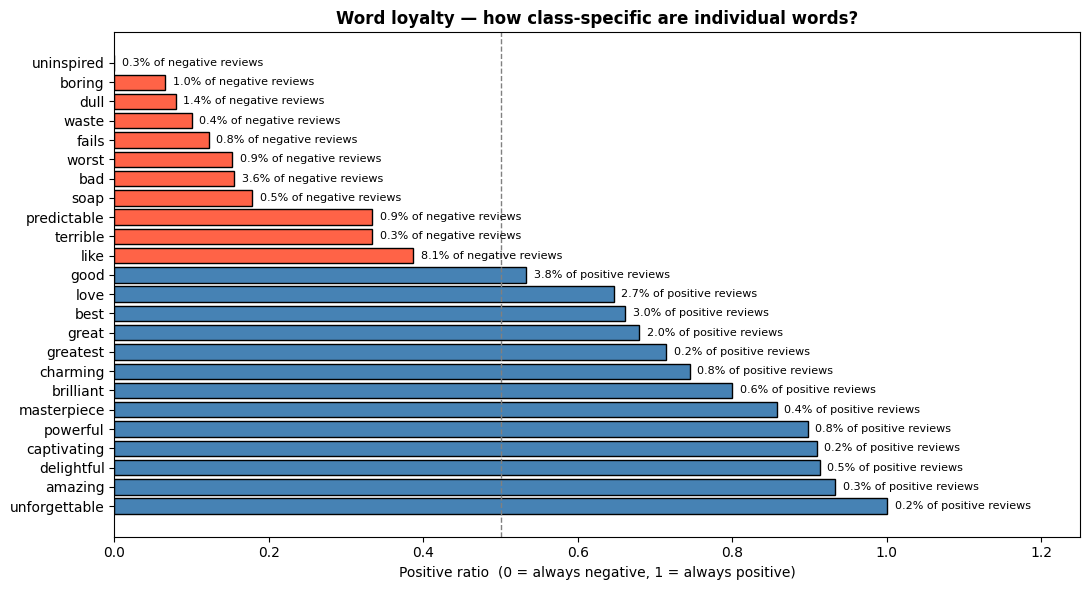

In [17]:
def word_loyalty(df, words):
    rows = []
    for w in words:
        p = df[df['label']==1]['text'].str.contains(rf'\b{w}\b', case=False).sum()
        n = df[df['label']==0]['text'].str.contains(rf'\b{w}\b', case=False).sum()
        rows.append({'word': w, 'pos_count': p, 'neg_count': n,
                     'total': p+n, 'pos_ratio': p/(p+n) if p+n else None})
    return pd.DataFrame(rows).dropna().sort_values('pos_ratio', ascending=False)

n_pos = (df['label'] == 1).sum()
n_neg = (df['label'] == 0).sum()

candidates = ['brilliant', 'masterpiece', 'delightful', 
              'charming', 'uninspired', 'predictable',
              'best', 'love', 'like', 'good', 'great', 'greatest', 'terrible',
              'amazing', 'unforgettable', 'powerful', 'captivating',
              'bad', 'boring', 'dull', 'worst', 'waste', 'fails', 'soap']

loyalty = word_loyalty(df, candidates)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(loyalty['word'], loyalty['pos_ratio'],
        color=[POS_COLOR if r >= 0.5 else NEG_COLOR
               for r in loyalty['pos_ratio']], edgecolor='black')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)

# Annotate each bar with the frequency in its dominant class
for i, (_, row) in enumerate(loyalty.iterrows()):
    if row['pos_ratio'] >= 0.5:
        freq = row['pos_count'] / n_pos
        label = f"{freq:.1%} of positive reviews"
        x = row['pos_ratio'] + 0.01
    else:
        freq = row['neg_count'] / n_neg
        label = f"{freq:.1%} of negative reviews"
        x = row['pos_ratio'] + 0.01
    ax.text(x, i, label, va='center', fontsize=8)

ax.set_xlim(0, 1.25)
ax.set_xlabel('Positive ratio  (0 = always negative, 1 = always positive)')
ax.set_title('Word loyalty — how class-specific are individual words?',
             fontweight='bold')
plt.tight_layout()
plt.show()

The hand-picked word loyalty analysis reveals a clear two-tier structure. Strong evaluative words — "unforgettable", "amazing", "delightful", "masterpiece", "brilliant" — are highly loyal to positive reviews (pos_ratio > 0.85) but appear in under 1% of them, so they are high-precision but low-recall signals. More frequent words like "good" (3.8%), "best" (3.0%), "bad" (3.6%) sit closer to 0.5, meaning they appear in both classes and are unsafe as standalone anchors. "like" is the most striking example — it appears in 8.1% of reviews yet leans slightly negative, likely because critics write "feels like" or "plays like" in negative comparisons. 

So I need to use strong evaluative words as anchors, but always combine them with negation and context checks.

### Domain Idioms

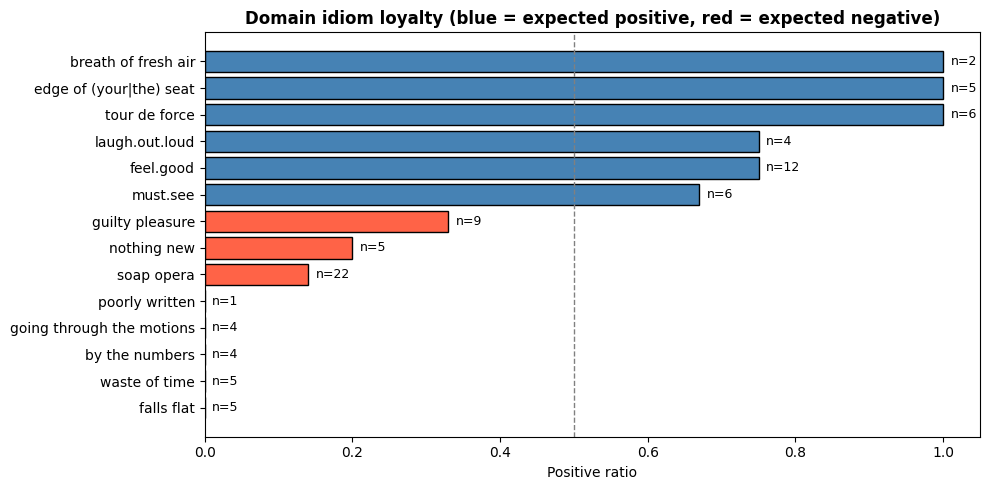

In [18]:
IDIOMS = {
    # negative
    'soap opera':                0,
    'falls flat':                0,
    'waste of time':             0,
    'by the numbers':            0,
    'going through the motions': 0,
    'nothing new':               0,
    'hard to watch':             0,
    'poorly written':            0,
    'guilty pleasure':           0,
    # positive
    'tour de force':             1,
    'must.see':                  1,   # covers "must see" and "must-see"
    'feel.good':                 1,   # covers "feel good" and "feel-good"
    'edge of (your|the) seat':   1,
    'breath of fresh air':       1,
    'laugh.out.loud':            1,
}

rows = []
for idiom, expected in IDIOMS.items():
    p = df[df['label']==1]['text'].str.contains(idiom, case=False, regex=True).sum()
    n = df[df['label']==0]['text'].str.contains(idiom, case=False, regex=True).sum()
    total = p + n
    if total:
        rows.append({'idiom': idiom, 'sentiment': 'positive' if expected else 'negative',
                     'pos_in_train': p, 'neg_in_train': n,
                     'total': total, 'pos_ratio': round(p/total, 2)})

idiom_df = pd.DataFrame(rows).sort_values('pos_ratio')

fig, ax = plt.subplots(figsize=(10, 5))
colors = [POS_COLOR if s == 'positive' else NEG_COLOR for s in idiom_df['sentiment']]
ax.barh(idiom_df['idiom'], idiom_df['pos_ratio'], color=colors, edgecolor='black')
ax.axvline(0.5, color='gray', linestyle='--', linewidth=1)
for i, (_, row) in enumerate(idiom_df.iterrows()):
    ax.text(row['pos_ratio'] + 0.01, i, f"n={row['total']}", va='center', fontsize=9)
ax.set_xlabel('Positive ratio')
ax.set_title('Domain idiom loyalty (blue = expected positive, red = expected negative)',
             fontweight='bold')
plt.tight_layout(); plt.show()

Domain idioms show a strong class loyalty. However, the same coverage problem applies here: these are high-precision but very low-recall signals. They make excellent hard anchors for regex rules, but will only fire on a tiny fraction of reviews.

### Negation Scope

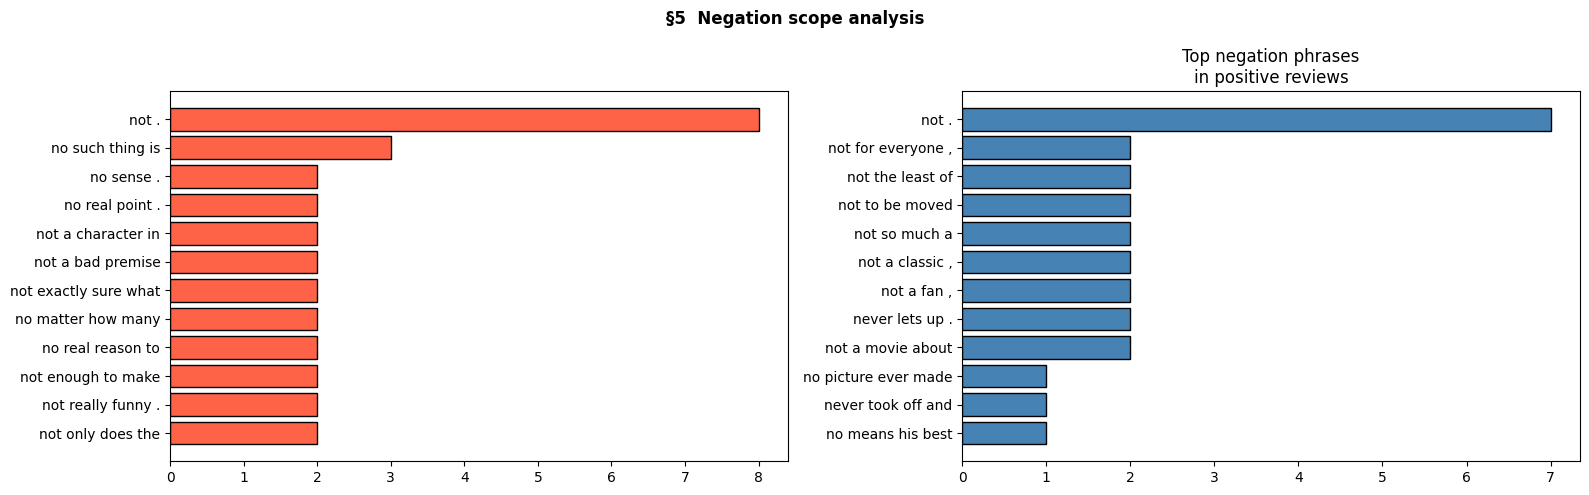

In [19]:
NEG_TERMS = {'not': r'\bnot\b', 'no': r'\bno\b', 'never': r'\bnever\b',
             "n't": r"\bn't\b", 'lack': r'\black(s|ing)?\b',
             'fails': r'\bfail(s|ed|ing|ure)?\b', 'without': r'\bwithout\b'}

rows = []
for term, pat in NEG_TERMS.items():
    p = df[df['label']==1]['text'].str.contains(pat, case=False, regex=True).mean()
    n = df[df['label']==0]['text'].str.contains(pat, case=False, regex=True).mean()
    rows.append({'term': term, 'positive': p, 'negative': n, 'neg_bias': n - p})

neg_term_df = pd.DataFrame(rows).sort_values('neg_bias', ascending=False)

# Most common phrases following each negation token
def negation_phrases(corpus, window=3):
    triggers = {'not', "n't", 'no', 'never'}
    phrases = []
    for text in corpus:
        tokens = text.lower().split()
        for i, tok in enumerate(tokens):
            clean = re.sub(r"[^a-z']", '', tok)
            if clean in triggers:
                phrases.append(' '.join([clean] + tokens[i+1:i+1+window]))
    return Counter(phrases)

top_neg_phrases = negation_phrases(df[df['label']==0]['text']).most_common(12)
top_pos_phrases = negation_phrases(df[df['label']==1]['text']).most_common(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top negation phrases in negative reviews
neg_ph_df = pd.DataFrame(top_neg_phrases, columns=['phrase', 'count'])
axes[0].barh(neg_ph_df['phrase'], neg_ph_df['count'], color=NEG_COLOR, edgecolor='black')
axes[0].invert_yaxis(); axes[1].set_title('Top negation phrases\nin negative reviews')

# Top negation phrases in positive reviews
pos_ph_df = pd.DataFrame(top_pos_phrases, columns=['phrase', 'count'])
axes[1].barh(pos_ph_df['phrase'], pos_ph_df['count'], color=POS_COLOR, edgecolor='black')
axes[1].invert_yaxis(); axes[1].set_title('Top negation phrases\nin positive reviews')

plt.suptitle('§5  Negation scope analysis', fontweight='bold')
plt.tight_layout(); plt.show()

As it was expected, what follows the negation matters more than the negation word itself, "not really funny" is negative, when "not for everyone" is positive. It will be difficult to capture via regex, but it will be possible to learn for ML/DL models.

### Concessive Conjunctions

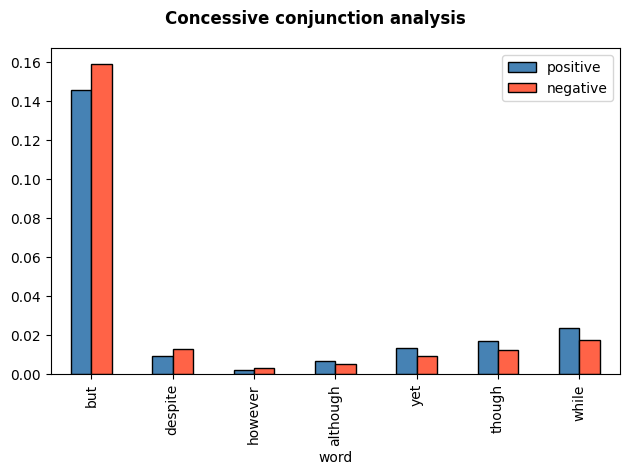

In [20]:
CONCESSIVES = ['but', 'however', 'although', 'yet', 'though', 'while', 'despite']

rows = []
for w in CONCESSIVES:
    p = df[df['label']==1]['text'].str.contains(rf'\b{w}\b', case=False).mean()
    n = df[df['label']==0]['text'].str.contains(rf'\b{w}\b', case=False).mean()
    rows.append({'word': w, 'positive': p, 'negative': n, 'neg_bias': n - p})

conc_df = pd.DataFrame(rows).sort_values('neg_bias', ascending=False)

df_conc          = df.copy()
conc_df.set_index('word')[['positive','negative']].plot(
    kind='bar', color=[POS_COLOR, NEG_COLOR], edgecolor='black')
axes[0].set_title('Concessive word frequency by class')
axes[0].set_ylabel('Proportion of reviews'); axes[0].tick_params(axis='x', rotation=30)


plt.suptitle('Concessive conjunction analysis', fontweight='bold')
plt.tight_layout()
plt.show()

No strong signals appear here either. “But” is used most frequently and tends to occur more often in negative reviews, but the difference is not substantial enough to serve as a standalone insight. None of the other concessives provide meaningful standalone insights either.

### INTENSIFIER + ADJECTIVE BIGRAMS — amplified sentiment

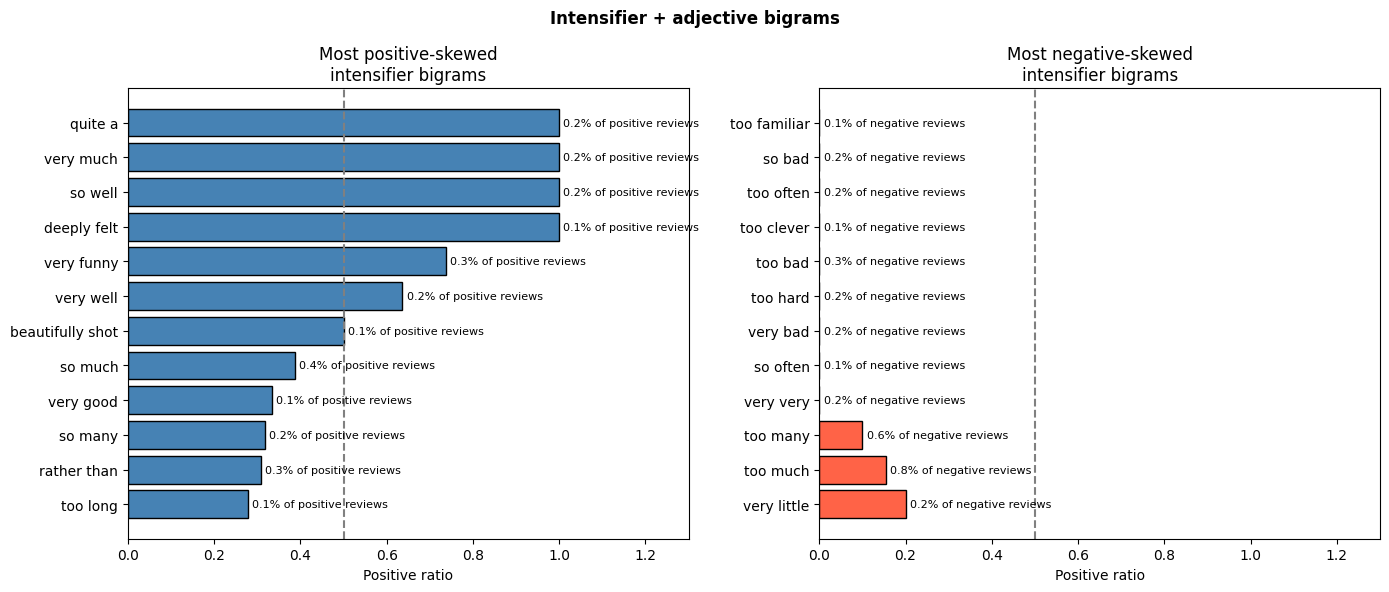

In [21]:
INTENSIFIERS = ['very', 'so', 'too', 'quite', 'absolutely', 'completely', 'utterly',
                'incredibly', 'remarkably', 'surprisingly', 'truly', 'deeply',
                'perfectly', 'entirely', 'highly', 'rather', 'extremely', 'terribly',
                'awfully', 'horribly', 'genuinely', 'thoroughly', 'hopelessly',
                'painfully', 'refreshingly', 'wonderfully', 'beautifully', 'badly',
                'desperately', 'sadly', 'unfortunately', 'undeniably', 'undoubtedly']

n_pos = (df['label'] == 1).sum()
n_neg = (df['label'] == 0).sum()

def intensifier_bigrams(corpus, top_n=40):
    pairs = []
    for text in corpus:
        tokens = re.findall(r"\b[a-z']+\b", text.lower())
        for i, tok in enumerate(tokens[:-1]):
            if tok in INTENSIFIERS:
                pairs.append(f"{tok} {tokens[i+1]}")
    return Counter(pairs).most_common(top_n)

pos_bigrams = dict(intensifier_bigrams(df[df['label']==1]['text']))
neg_bigrams = dict(intensifier_bigrams(df[df['label']==0]['text']))

all_bigrams = set(pos_bigrams) | set(neg_bigrams)
rows = []
for bg in all_bigrams:
    p, n = pos_bigrams.get(bg, 0), neg_bigrams.get(bg, 0)
    total = p + n
    if total >= 5:
        rows.append({'bigram': bg, 'pos_ratio': p/total,
                     'pos_freq': p/n_pos, 'neg_freq': n/n_neg, 'total': total})

int_df = pd.DataFrame(rows)
top_pos_int = int_df.nlargest(12, 'pos_ratio').sort_values('pos_ratio')
top_neg_int = int_df.nsmallest(12, 'pos_ratio').sort_values('pos_ratio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pos_int['bigram'], top_pos_int['pos_ratio'],
             color=POS_COLOR, edgecolor='black')
axes[0].axvline(0.5, color='gray', linestyle='--')
for i, (_, row) in enumerate(top_pos_int.iterrows()):
    axes[0].text(row['pos_ratio'] + 0.01, i,
                 f"{row['pos_freq']:.1%} of positive reviews",
                 va='center', fontsize=8)
axes[0].set_xlim(0, 1.3)
axes[0].set_title('Most positive-skewed\nintensifier bigrams')
axes[0].set_xlabel('Positive ratio')

axes[1].barh(top_neg_int['bigram'], top_neg_int['pos_ratio'],
             color=NEG_COLOR, edgecolor='black')
axes[1].axvline(0.5, color='gray', linestyle='--')
for i, (_, row) in enumerate(top_neg_int.iterrows()):
    axes[1].text(row['pos_ratio'] + 0.01, i,
                 f"{row['neg_freq']:.1%} of negative reviews",
                 va='center', fontsize=8)
axes[1].set_xlim(0, 1.3)
axes[1].set_title('Most negative-skewed\nintensifier bigrams')
axes[1].set_xlabel('Positive ratio')

plt.suptitle('Intensifier + adjective bigrams', fontweight='bold')
plt.tight_layout()
plt.show()

Intensifier bigrams show a meaningful but noisy signal. On the positive side, "very funny", "so well", "deeply felt", "beautifully shot" lean positive, with "very funny" being the most frequent at 0.3% of positive reviews. On the negative side, "too much" and "too many" are the standout patterns, critics using "too" to signal excess is a reliable negative indicator (0.8% and 0.6% of negative reviews respectively).

coverage is low across the board, but "too much" and "too many" stand out as the most actionable patterns here — frequent enough and sufficiently negative-skewed to serve as reliable regex signals.

### Top Discriminative Bigrams/Trigrams by Log Odds

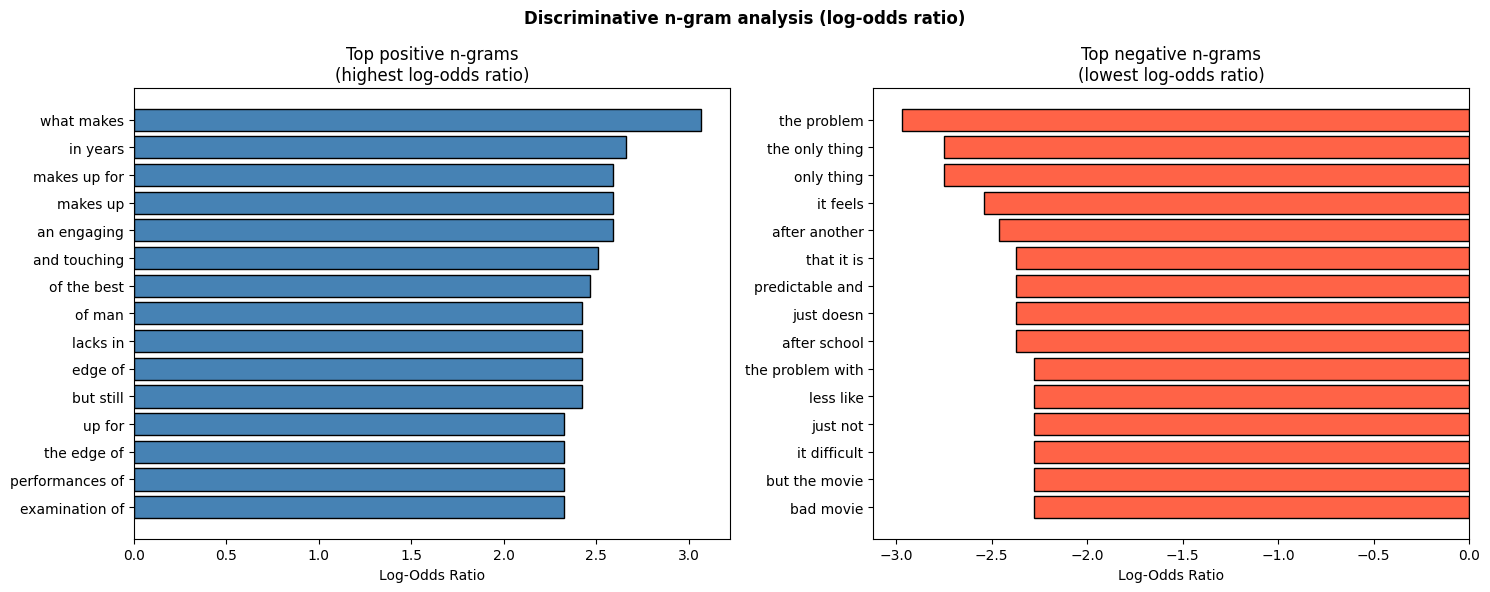

In [22]:
def log_odds(pos_corpus, neg_corpus, ngram_range=(2,3), min_df=5):
    vec = CountVectorizer(ngram_range=ngram_range, min_df=min_df, max_df=0.9)
    X   = vec.fit_transform(list(pos_corpus) + list(neg_corpus))
    labels = [1]*len(pos_corpus) + [0]*len(neg_corpus)
    vocab  = vec.get_feature_names_out()
    pf = np.asarray(X[np.array(labels)==1].sum(0)).flatten() + 1
    nf = np.asarray(X[np.array(labels)==0].sum(0)).flatten() + 1
    lor = np.log((pf/pf.sum()) / (nf/nf.sum()))
    return pd.DataFrame({'ngram': vocab, 'log_odds': lor,
                         'pos_count': pf-1, 'neg_count': nf-1})

lor_df  = log_odds(df[df['label']==1]['text'], df[df['label']==0]['text'])
top_pos = lor_df.nlargest(15, 'log_odds').sort_values('log_odds')
top_neg = lor_df.nsmallest(15, 'log_odds').sort_values('log_odds', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top_pos['ngram'], top_pos['log_odds'], color=POS_COLOR, edgecolor='black')
axes[0].set_title('Top positive n-grams\n(highest log-odds ratio)')
axes[0].set_xlabel('Log-Odds Ratio')

axes[1].barh(top_neg['ngram'], top_neg['log_odds'], color=NEG_COLOR, edgecolor='black')
axes[1].set_title('Top negative n-grams\n(lowest log-odds ratio)')
axes[1].set_xlabel('Log-Odds Ratio')

plt.suptitle('Discriminative n-gram analysis (log-odds ratio)', fontweight='bold')
plt.tight_layout(); plt.show()

The log-odds chart is the most statistically grounded view of discriminative phrases. On the positive side, "what makes" (critics explaining what works about a film), "makes up for", "of the best", "and touching", "edge of" and "performances of" dominate — these are the language of genuine appreciation and recommendation. On the negative side, "the problem", "the problem with", "the only thing", "it feels", "predictable and", "just doesn't", "just not", "bad movie" and "after school" stand out — the language of diagnosis and disappointment.

### Punctuation & Syntactic Signals

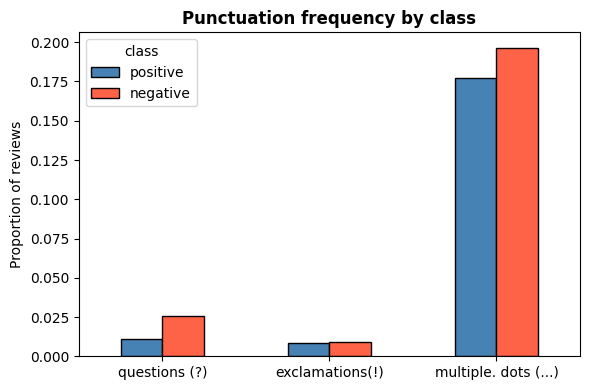

In [23]:
punct_rows = []
for label, name in [(1,'positive'), (0,'negative')]:
    sub = df[df['label']==label]['text']
    punct_rows.append({
        'class':          name,
        'questions (?)':  sub.str.contains(r'\?').mean(),
        'exclamations(!)':sub.str.contains(r'\!').mean(),
        'multiple. dots (...)':sub.str.contains(r'\...').mean(),
    })

punct_df = pd.DataFrame(punct_rows).set_index('class')

fig, ax = plt.subplots(figsize=(6, 4))
punct_df.T.plot(kind='bar', ax=ax,
                color=[POS_COLOR, NEG_COLOR], edgecolor='black')
ax.set_title('Punctuation frequency by class', fontweight='bold')
ax.set_ylabel('Proportion of reviews')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Question marks appear roughly 2.5× more often in negative reviews. Probably critics use rhetorical questions to express frustration or disbelief. 

Exclamation marks are nearly identical across classes, so they carry no useful signal and should be excluded from rules.

Multiple dots are slighly more common for the negative reviews.


### Stopwords Analysis

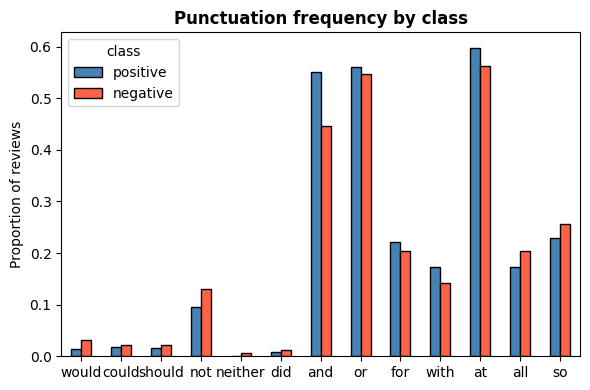

In [24]:
stopwords_rows = []
for label, name in [(1,'positive'), (0,'negative')]:
    sub = df[df['label']==label]['text']
    stopwords_rows.append({
        'class':          name,
        'would':  sub.str.contains(r'would').mean(),
        'could':sub.str.contains(r'could').mean(),
        'should':sub.str.contains(r'should').mean(),
        'not':sub.str.contains(r'not').mean(),
        'neither':sub.str.contains(r'neither').mean(),
        'did':sub.str.contains(r'did').mean(),
        'and':sub.str.contains(r'and').mean(),
        'or':sub.str.contains(r'or').mean(),
        'for':sub.str.contains(r'for').mean(),
        'with':sub.str.contains(r'with').mean(),
        'at':sub.str.contains(r'at').mean(),
        'all':sub.str.contains(r'all').mean(),
        'so':sub.str.contains(r'so').mean(),
    })

stopwords_df = pd.DataFrame(stopwords_rows).set_index('class')

fig, ax = plt.subplots(figsize=(6, 4))
stopwords_df.T.plot(kind='bar', ax=ax,
                color=[POS_COLOR, NEG_COLOR], edgecolor='black')
ax.set_title('Punctuation frequency by class', fontweight='bold')
ax.set_ylabel('Proportion of reviews')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

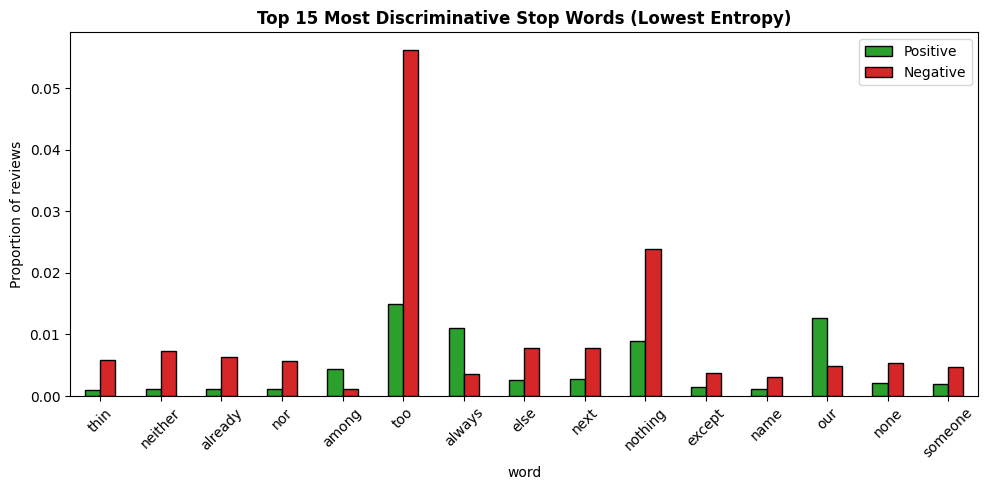

        word   entropy
48      thin  0.578795
60   neither  0.581321
119  already  0.625262
197      nor  0.663197
137    among  0.738285
168      too  0.742488
151   always  0.798244
15      else  0.811278
142     next  0.836641
206  nothing  0.843507
95    except  0.845351
6       name  0.852405
39       our  0.855451
114     none  0.857148
68   someone  0.863121


In [ ]:
# 1. Use CountVectorizer to instantly find which docs contain which stop words
vectorizer = CountVectorizer(vocabulary=ENGLISH_STOP_WORDS, binary=True)

X = vectorizer.fit_transform(df['text'])
words = vectorizer.get_feature_names_out()

# 2. Setup masks for positive and negative classes
pos_mask = df['label'] == 1
neg_mask = df['label'] == 0
pos_idx = np.flatnonzero(pos_mask.to_numpy())
neg_idx = np.flatnonzero(neg_mask.to_numpy())

# 3. Calculate occurrences in each class
pos_counts = np.asarray(X[pos_idx].sum(axis=0)).ravel()
neg_counts = np.asarray(X[neg_idx].sum(axis=0)).ravel()
total_counts = pos_counts + neg_counts

# 4. Filter out rare stop words (e.g., appearing in fewer than 15 reviews)
valid_mask = total_counts >= 15

# Proportions (What % of Positive docs have the word? What % of Negative?)
pos_props = pos_counts / pos_mask.sum()
neg_props = neg_counts / neg_mask.sum()

# 5. Calculate Probabilities for Entropy: P(Pos | Word) and P(Neg | Word)
p_pos_given_w = pos_counts[valid_mask] / total_counts[valid_mask]
p_neg_given_w = neg_counts[valid_mask] / total_counts[valid_mask]

# 6. Calculate Shannon Entropy (adding epsilon to avoid log(0) errors)
eps = 1e-9
entropy = -(
    p_pos_given_w * np.log2(p_pos_given_w + eps) +
    p_neg_given_w * np.log2(p_neg_given_w + eps)
)

# 7. Build DataFrame and sort by Lowest Entropy
top_discriminative_stopwords = pd.DataFrame({
    'word': words[valid_mask],
    'pos_prop': pos_props[valid_mask],
    'neg_prop': neg_props[valid_mask],
    'entropy': entropy
}).sort_values('entropy').head(15)

# 8. Plot the results
plot_df = top_discriminative_stopwords.set_index('word')[['pos_prop', 'neg_prop']]

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot(kind='bar', ax=ax, color=['#2ca02c', '#d62728'], edgecolor='black')

ax.set_title('Top 15 Most Discriminative Stop Words (Lowest Entropy)', fontweight='bold')
ax.set_ylabel('Proportion of reviews')
ax.legend(['Positive', 'Negative'])
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(top_discriminative_stopwords[['word', 'entropy']])


Some of the stopwords are more used in the negative comments, than in the positive ones, this information is useful for soft rules.

## Regex (Rule Based Sentiment Classifier)

The classifier is built around two types of rules: hard rules and soft rules.

Hard rules are high-confidence patterns — multi-word idioms and strongly polarised words that almost exclusively appear in one sentiment class (e.g. "tour de force", "waste of time"). When a hard rule fires, the decision is immediate with no further processing.

Soft rules are weaker signals — patterns that lean toward one class but appear in both. Rather than assigning a hard label, each matching soft pattern contributes one vote. The final prediction goes to whichever side accumulates more votes. This voting approach was motivated by the EDA: most individual words and short phrases appear in both positive and negative reviews, just with different frequencies, so a majority vote is more robust than any single pattern firing in isolation.

For the false positive reduction step, two additional mechanisms were added on top of the voting system:

**Negation scope** — words like "not", "never", "no" and contractions like "n't" open a negation window over the next few tokens. Any positive word that falls inside this window is counted as a negative vote instead, and any negative word is cancelled. For example, "not good" contributes a negative vote rather than a positive one.

**Concessive logic** — conjunctions like "but", "however" and "although" often signal a sentiment flip mid-review ("beautifully shot, but ultimately hollow"). When the clause after a concessive conjunction is net-negative, one positive vote is subtracted from the total to reflect the fact that the review is walking back its earlier praise.

### Positive/Negative Reviews Rule Creation

In [ ]:
# Hard rules fire immediately and bypass all voting
HARD_POSITIVE = [r'tour[\s\-]de[\s\-]force', r'edge of (your|the) seat', r'breath of fresh air']
HARD_NEGATIVE = [r'falls flat', r'waste of time', r'by the numbers', r'going through the motions']

# Soft patterns contribute one vote each
SOFT_POSITIVE = [
    r'feel[\s\-]good', r'must[\s\-]see', r'laugh[\s\-]out[\s\-]loud', r'coming[\s\-]of[\s\-]age',
    r'what makes', r'makes up for', r'of the best', r'one of the best', r'and touching',
    r'performances of', r'the best', r'romantic comedy', r'character study',
    r'psychological drama', r'thought[\s\-]provoking', r'love story', r'family film',
    r'very funny', r'so well', r'deeply felt', r'beautifully shot', r'wonderfully',
    r'very good', r'much better', r'really good', r'best film', r'greater',
    r'way', r'despite', r'good time', r'among', r'our', r'and'
]

SOFT_NEGATIVE = [
    r'soap opera', r'nothing new', r'hard to watch', r'poorly written', r'bad movie',
    r'the problem with', r'just doesn.t', r'predictable and', r'plays like', r'feels like',
    r'it feels like', r'too much', r'too many', r'too long', r'very bad', r'so bad',
    r'hopelessly', r'painfully', r'not enough', r'not very', r'\?', r'\...',
    r'would', r'could', r'should', r'too', r'much', r'more', r'thin', r'already',
    r'else', r'next', r'nothing', r'none'
]

# Lexicon used by the improved classifier for negation-aware word-level voting
POS_WORDS = {
    'unforgettable', 'masterpiece', 'amazing', 'brilliant', 'delightful', 'charming',
    'captivating', 'nuanced', 'touching', 'wonderful', 'funny', 'powerful', 'beautiful',
    'refreshing', 'genuine', 'best', 'great', 'good', 'love', 'fun', 'better', 'enjoyable',
    'solid', 'mesmerizing', 'riveting', 'enthralling', 'spellbinding', 'luminous', 'radiant',
    'poignant', 'heartfelt', 'tender', 'witty', 'sharp', 'clever', 'inventive', 'imaginative',
    'audacious', 'fearless', 'assured', 'confident', 'recommended', 'performances'
}
NEG_WORDS = {
    'boring', 'dull', 'terrible', 'awful', 'disappointing', 'predictable', 'formulaic',
    'derivative', 'uninspired', 'pointless', 'forgettable', 'mess', 'stupid', 'worst',
    'waste', 'bad', 'weak', 'dumb', 'disaster', 'silly', 'horrible', 'problem', 'tries'
}

# Baseline hard rules also include the word lexicons directly
HARD_POSITIVE_BASELINE = HARD_POSITIVE + list(POS_WORDS)
HARD_NEGATIVE_BASELINE = HARD_NEGATIVE + list(NEG_WORDS)

# Compiled patterns for negation and concessive detection
_NEGATION    = re.compile(r"\b(not|never|no|neither|nor)\b|n't", re.IGNORECASE)
_BOUNDARY    = re.compile(r'[.!?,;:]')
_CONCESSIVES = re.compile(r"\b(but|however|although|though|yet|despite)\b", re.IGNORECASE)
_RNG         = random.Random(SEED)

In [27]:
def get_negation_flags(tokens, window=4):
    # Returns a boolean mask: True where a token falls under negation scope.
    # Scope opens on negation words and resets at punctuation boundaries.
    flags, neg_until = [False] * len(tokens), -1
    for i, tok in enumerate(tokens):
        if _BOUNDARY.search(tok):    neg_until = -1
        elif _NEGATION.search(tok):  neg_until = i + window
        elif i <= neg_until:         flags[i] = True
    return flags


def count_votes(text, use_negation=False):

    pos = sum(1 for p in SOFT_POSITIVE    if re.search(p, text, re.IGNORECASE))
    neg = sum(1 for p in SOFT_NEGATIVE    if re.search(p, text, re.IGNORECASE))

    if use_negation:
        tokens = re.findall(r"\b\w+\b|[.!?,;:]", text.lower())
        flags  = get_negation_flags(tokens)
        for i, tok in enumerate(tokens):
            w = re.sub(r"[^a-z]", '', tok)
            if   w in POS_WORDS: neg += 1 if flags[i] else 0; pos += 0 if flags[i] else 1
            elif w in NEG_WORDS and not flags[i]: neg += 1

        parts = _CONCESSIVES.split(text)
        if len(parts) > 2:
            after = re.findall(r"\b\w+\b", ' '.join(parts[2::2]).lower())
            if sum(1 for t in after if t in NEG_WORDS) > sum(1 for t in after if t in POS_WORDS):
                pos = max(0, pos - 1)

    return pos, neg


def net_score(text, use_negation=False):
    pos, neg = count_votes(text, use_negation)
    return pos - neg


def classify(text, use_negation=False):
    hard_pos = HARD_POSITIVE if use_negation else HARD_POSITIVE_BASELINE
    hard_neg = HARD_NEGATIVE if use_negation else HARD_NEGATIVE_BASELINE
    if any(re.search(p, text, re.IGNORECASE) for p in hard_pos): return 1
    if any(re.search(p, text, re.IGNORECASE) for p in hard_neg): return 0
    pos, neg = count_votes(text, use_negation)
    if pos == neg:
        _RNG.seed(hash(text) % (2**32))   # seed from text content → same text always gets same result
        return _RNG.choice([0, 1])
    return 1 if pos > neg else 0


def evaluate(df, split_name, use_negation=False):
    preds  = df['text'].apply(lambda t: classify(t, use_negation))
    votes  = df['text'].apply(lambda t: count_votes(t, use_negation))
    hard   = (HARD_POSITIVE + HARD_NEGATIVE) if use_negation else (HARD_POSITIVE_BASELINE + HARD_NEGATIVE_BASELINE)
    covered = df[
        votes.apply(lambda v: v[0] + v[1] > 0) |
        df['text'].apply(lambda t: any(re.search(p, t, re.IGNORECASE) for p in hard))
    ]
    print(f"\n{split_name} | covered {len(covered)}/{len(df)} ({len(covered)/len(df):.1%})")
    print(f"Accuracy: {accuracy_score(df['label'], preds):.3f}")
    print(classification_report(df['label'], preds, target_names=['negative', 'positive']))
    return preds

In [28]:
_ = evaluate(df_val,  "Validation", use_negation=False)
_ = evaluate(df_test, "Test",       use_negation=False)


Validation | covered 863/1066 (81.0%)
Accuracy: 0.592
              precision    recall  f1-score   support

    negative       0.62      0.48      0.54       533
    positive       0.57      0.71      0.63       533

    accuracy                           0.59      1066
   macro avg       0.60      0.59      0.59      1066
weighted avg       0.60      0.59      0.59      1066


Test | covered 885/1066 (83.0%)
Accuracy: 0.604
              precision    recall  f1-score   support

    negative       0.64      0.48      0.55       533
    positive       0.58      0.72      0.65       533

    accuracy                           0.60      1066
   macro avg       0.61      0.60      0.60      1066
weighted avg       0.61      0.60      0.60      1066



The baseline classifier reaches 59% and 60% accuracy on the validation and test sets. Coverage is around 81–83%, meaning roughly 1 in 5 reviews gets no rule match and falls back to a random guess.

Precision is noticeably lower for the positive class (0.57-0.58) than for negative (0.62–0.64), which indicates the soft positive patterns fire too broadly — the model predicts positive more often than it should. This false positive tendency is the main weakness to address in the next step.

### Reducing False Positives

The baseline has a clear positive bias: precision for the positive class (0.58) is lower than for negative (0.62–0.64), meaning the model over-predicts positive. I explore two separate fixes to understand where the false positives actually come from.

#### Step 1 — Negation and concessive logic

The first hypothesis is that some false positives come from positive words appearing under negation ("not good", "never brilliant") or in a concessive structure ("beautifully shot, but ultimately hollow"). Adding negation scope and concessive adjustment should convert some of those erroneous positive votes into negative ones.

                Model  Accuracy  Pos Precision  Pos Recall  False Positives  False Negatives
             Baseline     0.604          0.584       0.724              275              147
+ Negation/Concessive     0.595          0.580       0.685              264              168


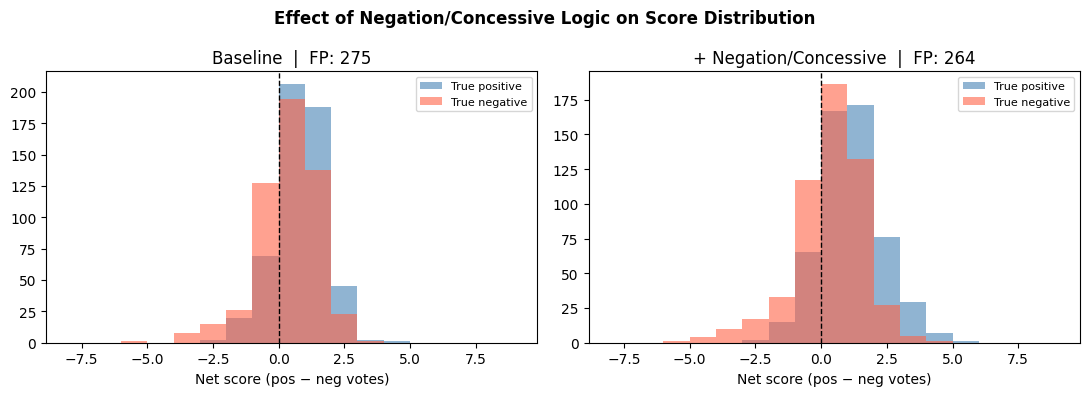

In [29]:
# Evaluate with negation/concessive added but 'and' still in the list
preds_base = df_test['text'].apply(lambda t: classify(t, use_negation=False))
preds_neg  = df_test['text'].apply(lambda t: classify(t, use_negation=True))
true       = df_test['label']

def fp_fn(preds, true):
    fp = ((preds == 1) & (true == 0)).sum()
    fn = ((preds == 0) & (true == 1)).sum()
    return fp, fn

fp_b, fn_b = fp_fn(preds_base, true)
fp_n, fn_n = fp_fn(preds_neg,  true)

cmp_neg = pd.DataFrame([
    {'Model': 'Baseline',              'Accuracy': accuracy_score(true, preds_base),
     'Pos Precision': precision_score(true, preds_base),
     'Pos Recall': recall_score(true, preds_base),
     'False Positives': fp_b, 'False Negatives': fn_b},
    {'Model': '+ Negation/Concessive', 'Accuracy': accuracy_score(true, preds_neg),
     'Pos Precision': precision_score(true, preds_neg),
     'Pos Recall': recall_score(true, preds_neg),
     'False Positives': fp_n, 'False Negatives': fn_n},
]).round(3)
print(cmp_neg.to_string(index=False))

# Visualise FP/FN change
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, use_neg, title in [(axes[0], False, 'Baseline'), (axes[1], True, '+ Negation/Concessive')]:
    scores  = df_test['text'].apply(lambda t: net_score(t, use_neg))
    ax.hist(scores[true == 1], bins=range(-8, 10), alpha=0.6, color='steelblue', label='True positive')
    ax.hist(scores[true == 0], bins=range(-8, 10), alpha=0.6, color='tomato',    label='True negative')
    ax.axvline(0, color='black', linestyle='--', lw=1)
    fp = ((df_test['text'].apply(lambda t: classify(t, use_neg)) == 1) & (true == 0)).sum()
    ax.set_title(f'{title}  |  FP: {fp}')
    ax.set_xlabel('Net score (pos − neg votes)')
    ax.legend(fontsize=8)

plt.suptitle('Effect of Negation/Concessive Logic on Score Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

Negation and concessive logic reduce false positives slightly (275 → 264) but hurt recall (0.724 → 0.685) and drop overall accuracy from 0.604 to 0.595. The added complexity is not paying off — on short critic snippets, negated constructions are rare enough that the rules penalise more correct positive predictions than they fix false ones.

#### Step 2 — Removing 'and' from soft positives

A different angle: rather than adding complexity, remove a rule that is too broad to be useful. During EDA, 'and' appeared more frequently in positive reviews, which is why it was included. But the skew is small, 'and' is common in almost every review regardless of sentiment, so it contributes noise more than signal.

Removing it is a deliberate tradeoff. Fewer reviews will accumulate enough positive votes to cross the decision boundary, so:
- **False positives fall** — reviews that were only tipping positive because of 'and' now get classified correctly or abstained on.
- **Recall of the positive class falls** — some genuinely positive reviews that relied on 'and' as their only or decisive vote now get missed.
- **Coverage shrinks** — fewer reviews are "covered" by any rule, meaning more fall through to the random fallback.

If the goal is precision — e.g. the cost of a false positive is high — it is better to be conservative and only fire rules that are strongly skewed toward one class.

                Model  Accuracy  Pos Precision  Pos Recall  False Positives  False Negatives
             Baseline     0.592          0.575       0.707              279              156
+ Negation/Concessive     0.592          0.577       0.689              269              166
     Baseline − "and"     0.578          0.581       0.559              215              235


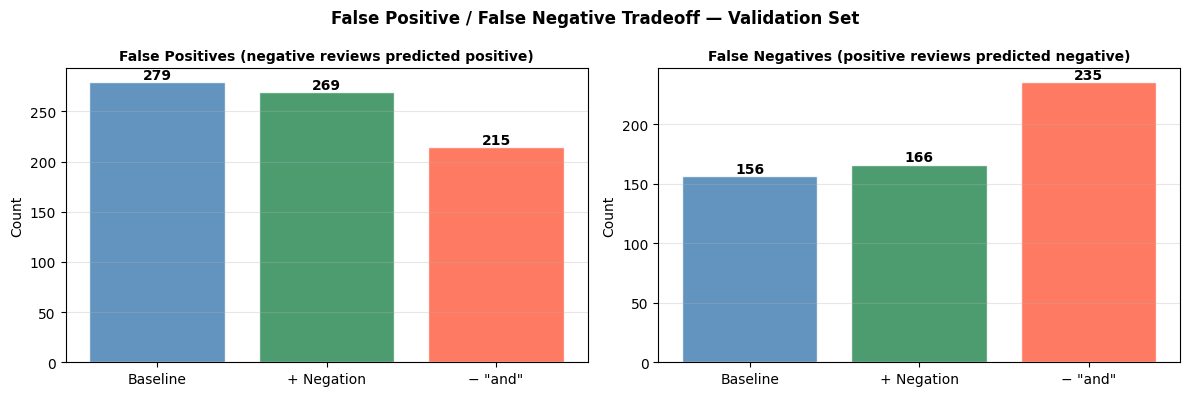

In [33]:
SOFT_POSITIVE_NO_AND = [p for p in SOFT_POSITIVE if p != r'and']

def classify_no_and(text):
    if any(re.search(p, text, re.IGNORECASE) for p in HARD_POSITIVE_BASELINE): return 1
    if any(re.search(p, text, re.IGNORECASE) for p in HARD_NEGATIVE_BASELINE): return 0
    pos = sum(1 for p in SOFT_POSITIVE_NO_AND if re.search(p, text, re.IGNORECASE))
    neg = sum(1 for p in SOFT_NEGATIVE        if re.search(p, text, re.IGNORECASE))
    if pos == neg:
        _RNG.seed(hash(text) % (2**32))
        return _RNG.choice([0, 1])
    return 1 if pos > neg else 0

true         = df_val['label']
preds_base   = df_val['text'].apply(lambda t: classify(t, use_negation=False))
preds_neg    = df_val['text'].apply(lambda t: classify(t, use_negation=True))
preds_no_and = df_val['text'].apply(classify_no_and)

fp_b, fn_b = fp_fn(preds_base,   true)
fp_n, fn_n = fp_fn(preds_neg,    true)
fp_a, fn_a = fp_fn(preds_no_and, true)

cmp_all = pd.DataFrame([
    {'Model': 'Baseline',              'Accuracy': accuracy_score(true, preds_base),
     'Pos Precision': precision_score(true, preds_base),   'Pos Recall': recall_score(true, preds_base),
     'False Positives': fp_b, 'False Negatives': fn_b},
    {'Model': '+ Negation/Concessive', 'Accuracy': accuracy_score(true, preds_neg),
     'Pos Precision': precision_score(true, preds_neg),    'Pos Recall': recall_score(true, preds_neg),
     'False Positives': fp_n, 'False Negatives': fn_n},
    {'Model': 'Baseline − "and"',      'Accuracy': accuracy_score(true, preds_no_and),
     'Pos Precision': precision_score(true, preds_no_and), 'Pos Recall': recall_score(true, preds_no_and),
     'False Positives': fp_a, 'False Negatives': fn_a},
]).round(3)
print(cmp_all.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
models = ['Baseline', '+ Negation', '− "and"']
colors = ['steelblue', 'seagreen', 'tomato']

for ax, vals, title in [
    (axes[0], [fp_b, fp_n, fp_a], 'False Positives (negative reviews predicted positive)'),
    (axes[1], [fn_b, fn_n, fn_a], 'False Negatives (positive reviews predicted negative)'),
]:
    bars = ax.bar(models, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('False Positive / False Negative Tradeoff — Validation Set', fontweight='bold')
plt.tight_layout(); plt.show()

Negation and concessive logic reduce false positives slightly (279 → 269) but leave accuracy unchanged at 0.592, confirming that complex linguistic rules add little value on short critic snippets where negation is rare.

Removing 'and' produces the largest shift in false positives (279 → 215) and improves precision (0.575 → 0.581), but recall drops sharply (0.707 → 0.559) and false negatives nearly double (156 → 235), pulling overall accuracy down to 0.578. The 'and' pattern was inflating positive predictions, but it was also carrying genuine signal for many positive reviews.

#### Overall Conclusion

All three variants perform similarly, pointing to a ceiling of the rule-based approach on this dataset. Since negation logic offers no accuracy gain and removing 'and' hurts overall performance, the baseline is the best choice — it achieves the highest accuracy with the simplest logic and the best recall.

### Save the Results

In [34]:
# Final model: baseline classifier (no negation, 'and' retained)
# Ties on accuracy with the no-'and' variant but has better recall
_RNG.seed(hash('val') % (2**32))
preds_final = df_test['text'].apply(lambda t: classify(t, use_negation=False))
preds_val   = df_val['text'].apply(lambda t: classify(t, use_negation=False))

model_results['rule_based'] = {
    'Model'         : 'Rule-Based',
    'Val Accuracy'  : round(accuracy_score(df_val['label'],  preds_val),   4),
    'Test Accuracy' : round(accuracy_score(df_test['label'], preds_final), 4),
    'Test Precision': round(precision_score(df_test['label'], preds_final), 4),
    'Test Recall'   : round(recall_score(df_test['label'],   preds_final), 4),
    'Test F1'       : round(f1_score(df_test['label'], preds_final, average='macro'), 4),
}
print(model_results['rule_based'])

{'Model': 'Rule-Based', 'Val Accuracy': 0.5919, 'Test Accuracy': 0.6041, 'Test Precision': 0.584, 'Test Recall': 0.7242, 'Test F1': 0.5983}


# Machine Learning with TF-IDF and Logistic Regression

## EDA

Total vocabulary size: 16474
Words appearing in only 1 review: 7744
Words appearing in < 5 reviews: 12652


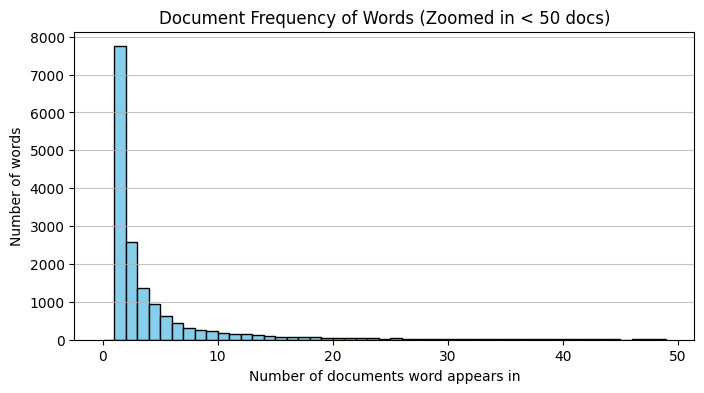

In [ ]:
# 1. Calculate Document Frequency (DF) for all words
temp_vec = CountVectorizer()
X_temp = temp_vec.fit_transform(df['text']) # Using your EDA train set

# Sum the columns (boolean mask > 0) to get document frequency per word
doc_frequencies = np.array((X_temp > 0).sum(axis=0)).flatten()

# 2. Analyze the sparsity
print(f"Total vocabulary size: {len(doc_frequencies)}")
print(f"Words appearing in only 1 review: {(doc_frequencies == 1).sum()}")
print(f"Words appearing in < 5 reviews: {(doc_frequencies < 5).sum()}")

# 3. Plot the cumulative distribution of Document Frequencies
# We cut off the x-axis at 50 documents to see the "long tail" of rare words clearly
plt.figure(figsize=(8, 4))
plt.hist(doc_frequencies, bins=np.arange(0, 50, 1), color='skyblue', edgecolor='black')
plt.title('Document Frequency of Words (Zoomed in < 50 docs)')
plt.xlabel('Number of documents word appears in')
plt.ylabel('Number of words')
plt.grid(axis='y', alpha=0.75)
plt.show()

The raw vocabulary contains 16,474 unique words, of which 76.8% appear in fewer than 5 reviews. These are mostly typos, rare proper nouns, and noise — filtering them with min_df=5 reduces the vocabulary to 3,566 meaningful terms.

## Threshold Finding Function

In [36]:
def optimize_and_evaluate(y_val_true, y_val_probs, y_test_true, y_test_probs, model_name):
    # 1. Plot the Prediction Score Distributions
    plt.figure(figsize=(8, 4))
    sns.histplot(y_val_probs[y_val_true == 0], color='red', label='True Negative', kde=True, stat='density', alpha=0.5)
    sns.histplot(y_val_probs[y_val_true == 1], color='green', label='True Positive', kde=True, stat='density', alpha=0.5)
    
    plt.title(f'[{model_name}] - Validation Probability Distribution')
    plt.xlabel('Predicted Probability of being Positive')
    plt.ylabel('Density')
    plt.axvline(0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.legend()
    plt.show()

    # 2. Find the optimal threshold on the Validation Set
    thresholds = np.linspace(0.1, 0.9, 81) # Check every 0.01 between 0.1 and 0.9
    best_thresh = 0.5
    best_acc = 0

    for t in thresholds:
        preds = (y_val_probs >= t).astype(int)
        acc = accuracy_score(y_val_true, preds)
        if acc > best_acc:
            best_acc = acc
            best_thresh = t

    print(f"Optimal Validation Threshold: {best_thresh:.2f} (Val Accuracy: {best_acc:.4f})")

    # 3. Apply the optimal threshold to the TEST SET
    test_preds = (y_test_probs >= best_thresh).astype(int)
    test_acc = accuracy_score(y_test_true, test_preds)
    
    print(f"--- TEST SET RESULTS ({model_name}) ---")
    print(f"Test Accuracy using {best_thresh:.2f} threshold: {test_acc:.4f}")
    print(classification_report(y_test_true, test_preds, target_names=['Negative', 'Positive']))
    print("=" * 70 + "\n")

In [ ]:
# Grab test labels
y_test = df_test['label']

# Tokenize test text for the Word2Vec models
test_tokens = [word_tokenize(text.lower()) for text in df_test['text']]

## Baseline Model

Raw vocab: 16,474 words
Appearing in < 5 docs: 12,652 (76.8%) — removed by min_df=5

Vocab after filtering: 3,566
Val Accuracy: 0.7373

              precision    recall  f1-score   support

    Negative       0.72      0.77      0.74       533
    Positive       0.75      0.71      0.73       533

    accuracy                           0.74      1066
   macro avg       0.74      0.74      0.74      1066
weighted avg       0.74      0.74      0.74      1066



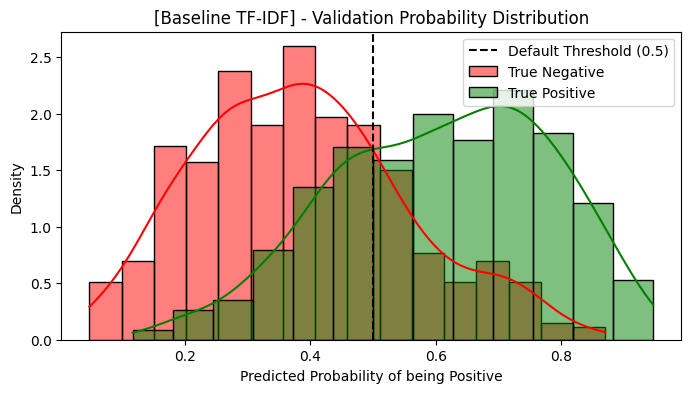

Optimal Validation Threshold: 0.53 (Val Accuracy: 0.7458)
--- TEST SET RESULTS (Baseline TF-IDF) ---
Test Accuracy using 0.53 threshold: 0.7561
              precision    recall  f1-score   support

    Negative       0.74      0.79      0.76       533
    Positive       0.78      0.72      0.75       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066




In [ ]:
y_train, y_val, y_test = df_train['label'], df_val['label'], df_test['label']

# Sparsity check — justifies min_df=5 filtering
doc_freq = np.array(
    (CountVectorizer().fit_transform(df_train['text']) > 0).sum(axis=0)
).flatten()
print(f"Raw vocab: {len(doc_freq):,} words")
print(f"Appearing in < 5 docs: {(doc_freq < 5).sum():,} ({(doc_freq < 5).mean():.1%}) — removed by min_df=5\n")

# Baseline: unigrams, English stop words removed, rare/universal terms filtered
tfidf         = TfidfVectorizer(stop_words='english', min_df=5, max_df=0.8)
X_train_tfidf = tfidf.fit_transform(df_train['text'])
X_val_tfidf   = tfidf.transform(df_val['text'])
X_test_tfidf  = tfidf.transform(df_test['text'])

# No StandardScaler — TF-IDF's built-in L2 row normalisation already puts
# features on a comparable scale; StandardScaler amplifies rare noisy features
lr_model = LogisticRegression(random_state=SEED, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

print(f"Vocab after filtering: {len(tfidf.vocabulary_):,}")
print(f"Val Accuracy: {accuracy_score(y_val, lr_model.predict(X_val_tfidf)):.4f}\n")
print(classification_report(y_val, lr_model.predict(X_val_tfidf),
                             target_names=['Negative', 'Positive']))

# Test evaluation with optimal threshold
optimize_and_evaluate(
    y_val,  lr_model.predict_proba(X_val_tfidf)[:, 1],
    y_test, lr_model.predict_proba(X_test_tfidf)[:, 1],
    'Baseline TF-IDF'
)

The baseline achieves 0.74 validation accuracy with 3,566 features — a substantial jump over the rule-based classifier. The optimal threshold (0.53) is close to the default 0.5, indicating the model is well-calibrated. Test accuracy (0.756) is slightly higher than validation, suggesting no overfitting.

### Feature Importances

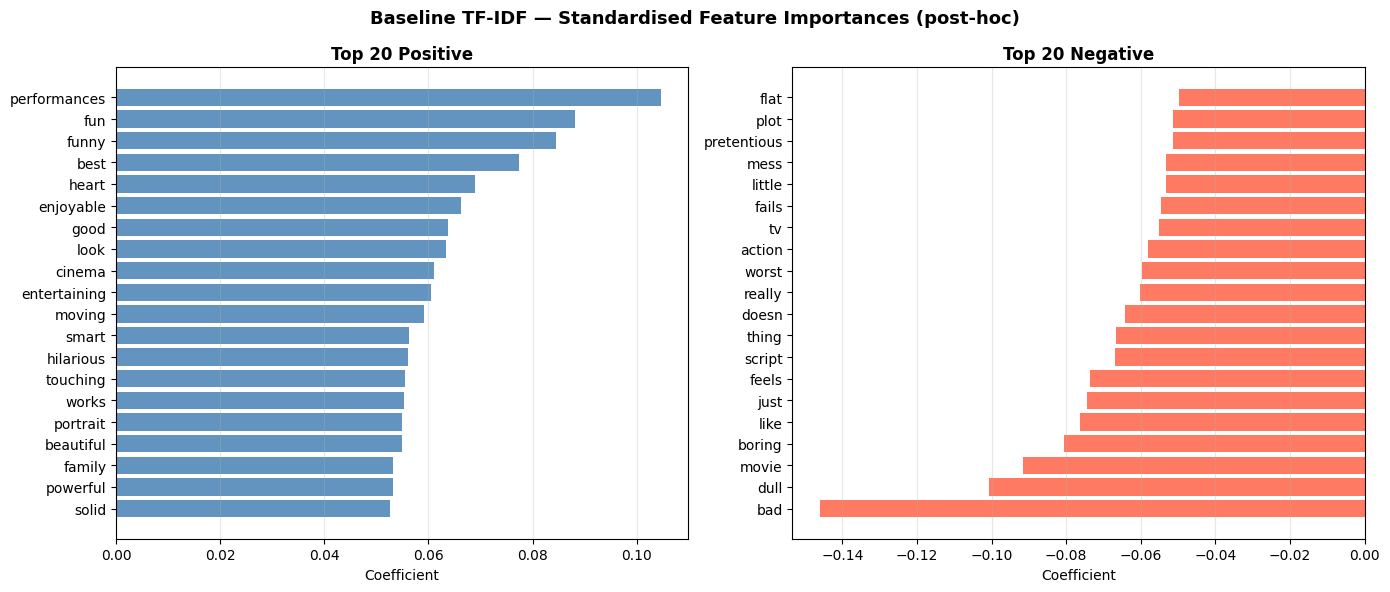

In [39]:
def plot_top_features(feature_names, coefs, n=20, title=''):
    df_imp  = pd.DataFrame({'feature': feature_names, 'coef': coefs})
    top_pos = df_imp.nlargest(n,  'coef').iloc[::-1]
    top_neg = df_imp.nsmallest(n, 'coef')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, data, color, label in [
        (axes[0], top_pos, 'steelblue', f'Top {n} Positive'),
        (axes[1], top_neg, 'tomato',    f'Top {n} Negative'),
    ]:
        ax.barh(data['feature'], data['coef'], color=color, alpha=0.85)
        ax.set_title(label, fontweight='bold')
        ax.set_xlabel('Coefficient')
        ax.grid(axis='x', alpha=0.3)
    plt.suptitle(title, fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

# Post-hoc standardised importance for interpretability
feature_stds  = np.asarray(X_train_tfidf.power(2).mean(axis=0)).flatten() ** 0.5
scaled_coefs  = lr_model.coef_[0] * feature_stds

plot_top_features(tfidf.get_feature_names_out(), scaled_coefs,
                  title='Baseline TF-IDF — Standardised Feature Importances (post-hoc)')

The post-hoc standardised importances are clean and interpretable. "performances", "fun", "funny", "best" are the strongest positive predictors — these match what a human reviewer would associate with praise. On the negative side, "bad" and "dull" dominate by a clear margin. Several quasi-stop words appear as negative features: "movie", "script", "like", "just", "doesn". This reflects a genuine pattern in the data — negative reviews tend to use more hedging and descriptive language about plot mechanics ("the movie fails to...", "the script doesn't..."), whereas positive reviews use more direct evaluative adjectives.

## Preprocessing experiments

In [ ]:
nltk.download('wordnet', quiet=True)

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_text(text):
    return ' '.join(stemmer.stem(t) for t in text.lower().split())

def lemmatize_text(text):
    return ' '.join(lemmatizer.lemmatize(t) for t in text.lower().split())

NGRAM_PARAMS = dict(ngram_range=(1, 3), min_df=3, max_df=0.9)

variants = {
    'N-gram (no preprocessing)': (df_train['text'],                        df_val['text'],                        df_test['text']),
    'N-gram + stop words'       : (df_train['text'],                        df_val['text'],                        df_test['text']),
    'N-gram + stemming'         : (df_train['text'].apply(stem_text),        df_val['text'].apply(stem_text),        df_test['text'].apply(stem_text)),
    'N-gram + lemmatization'    : (df_train['text'].apply(lemmatize_text),   df_val['text'].apply(lemmatize_text),   df_test['text'].apply(lemmatize_text)),
}

rows = []
for name, (tr, va, te) in variants.items():
    sw  = 'english' if 'stop words' in name else None
    vec = TfidfVectorizer(**NGRAM_PARAMS, stop_words=sw)
    Xtr = vec.fit_transform(tr); Xva = vec.transform(va); Xte = vec.transform(te)
    mdl = LogisticRegression(random_state=SEED, max_iter=1000)
    mdl.fit(Xtr, y_train)

    val_probs  = mdl.predict_proba(Xva)[:, 1]
    test_probs = mdl.predict_proba(Xte)[:, 1]

    # Optimal threshold selected on validation only
    thresholds = np.linspace(0.1, 0.9, 81)
    best_t     = max(thresholds,
                     key=lambda t: accuracy_score(y_val, (val_probs >= t).astype(int)))

    rows.append({
        'Variant'    : name,
        'Val Acc'    : round(accuracy_score(y_val,  (val_probs  >= best_t).astype(int)), 4),
        'Test Acc'   : round(accuracy_score(y_test, (test_probs >= best_t).astype(int)), 4),
        'Test F1'    : round(f1_score(y_test,       (test_probs >= best_t).astype(int), average='macro'), 4),
        'Threshold'  : round(best_t, 2),
        '_val_probs' : val_probs,
        '_test_probs': test_probs,
        '_vec'       : vec,
        '_mdl'       : mdl,
        '_best_t'    : best_t,
    })

# Summary table
results_df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in rows])
print(results_df.to_string(index=False))

# Detailed classification reports at the selected threshold
for r in rows:
    val_preds  = (r['_val_probs']  >= r['_best_t']).astype(int)
    test_preds = (r['_test_probs'] >= r['_best_t']).astype(int)
    print(f"\n── {r['Variant']} (threshold={r['_best_t']:.2f}) ──")
    print(f"Validation:\n{classification_report(y_val,  val_preds,  target_names=['Negative', 'Positive'])}")
    print(f"Test:\n{classification_report(y_test, test_preds, target_names=['Negative', 'Positive'])}")

# Best model selected by validation accuracy
best_row       = max(rows, key=lambda r: r['Val Acc'])
tfidf_best     = best_row['_vec']
lr_model_best  = best_row['_mdl']
best_threshold = best_row['_best_t']
print(f"\nBest variant: {best_row['Variant']}  |  Val Acc: {best_row['Val Acc']}  |  Threshold: {best_threshold:.2f}")

                  Variant  Val Acc  Test Acc  Test F1  Threshold
N-gram (no preprocessing)   0.7542    0.7767   0.7764       0.47
      N-gram + stop words   0.7505    0.7523   0.7520       0.53
        N-gram + stemming   0.7523    0.7842   0.7841       0.48
   N-gram + lemmatization   0.7486    0.7786   0.7785       0.48

── N-gram (no preprocessing) (threshold=0.47) ──
Validation:
              precision    recall  f1-score   support

    Negative       0.79      0.69      0.74       533
    Positive       0.73      0.81      0.77       533

    accuracy                           0.75      1066
   macro avg       0.76      0.75      0.75      1066
weighted avg       0.76      0.75      0.75      1066

Test:
              precision    recall  f1-score   support

    Negative       0.80      0.74      0.77       533
    Positive       0.76      0.81      0.78       533

    accuracy                           0.78      1066
   macro avg       0.78      0.78      0.78      1066
weighted

Extending to n-grams is the single most impactful change, improving test accuracy from 0.756 to 0.777. Adding stop word removal hurts (0.752) — confirming that function words like "not", "no", "too" contribute meaningful signal when they appear in bigrams and trigrams such as "fails to", "not worth", "plays like". Stemming and lemmatization each produce marginal additional gains on the validation set by merging inflected word forms.

The best model by validation accuracy is n-gram without additional text preprocessing (val 0.754, test 0.777), which is what I carry forward.

The fact that bigrams and trigrams were impactful is not surprising, as they give us more context, which is necessary to get more precise predictions.

### Feature importance of best model

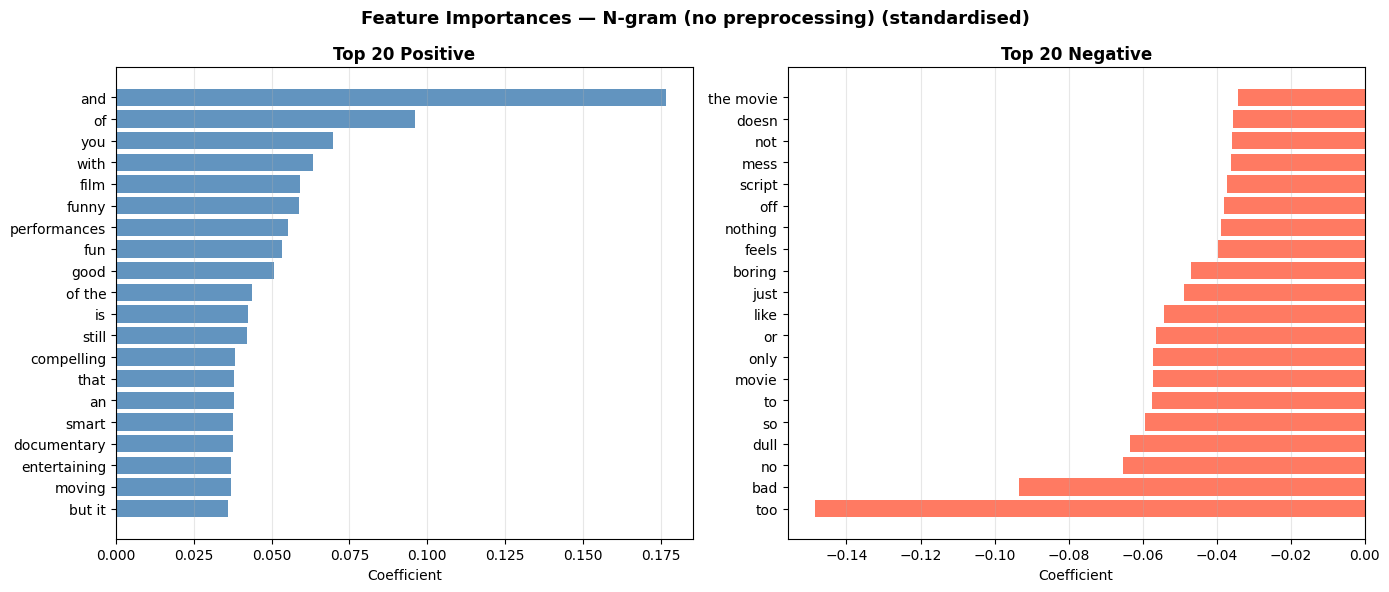

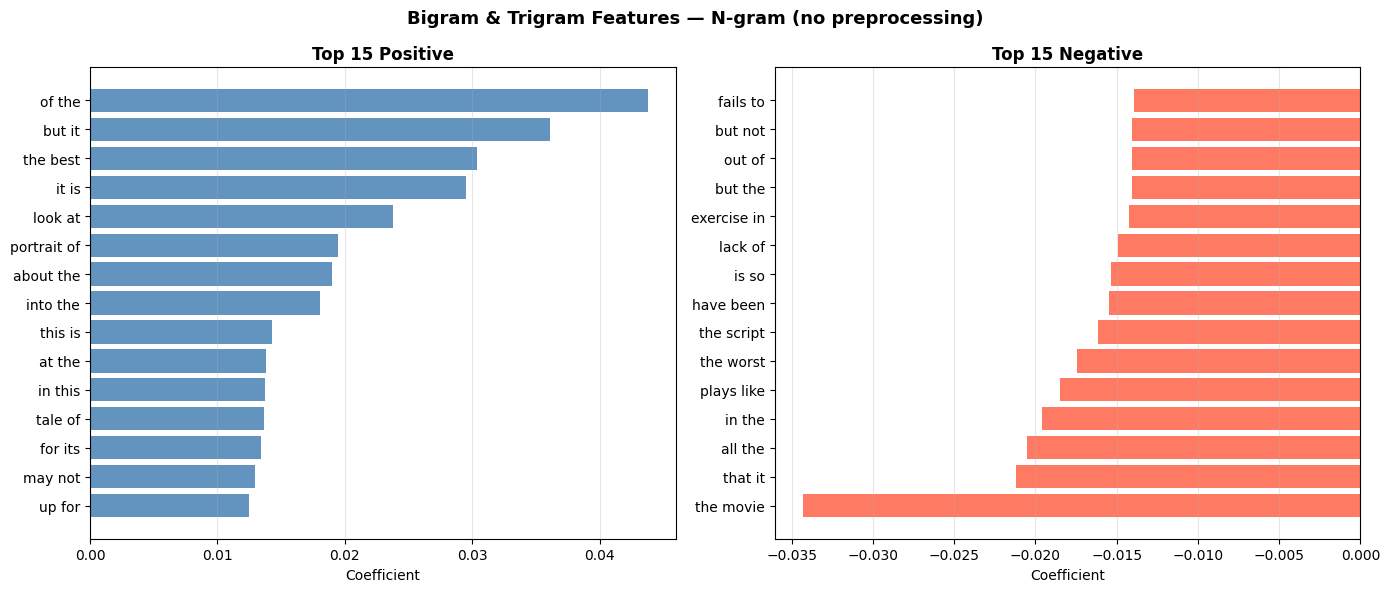

In [41]:
# Best preprocessing variant
best_idx  = results_df['Val Acc'].idxmax()
best_name = results_df.loc[best_idx, 'Variant']

# Preprocess text for the best variant
def apply_best_preprocessing(series):
    if 'lemma' in best_name.lower(): return series.apply(lemmatize_text)
    if 'stem'  in best_name.lower(): return series.apply(stem_text)
    return series

X_train_best = tfidf_best.transform(apply_best_preprocessing(df_train['text']))
X_val_best   = tfidf_best.transform(apply_best_preprocessing(df_val['text']))
X_test_best  = tfidf_best.transform(apply_best_preprocessing(df_test['text']))

# Post-hoc standardised coefficients — multiply by each feature's std for comparability
feature_stds = np.asarray(X_train_best.power(2).mean(axis=0)).flatten() ** 0.5
scaled_coefs = lr_model_best.coef_[0] * feature_stds

ng_names = tfidf_best.get_feature_names_out()

# All features with standardised coefficients
plot_top_features(ng_names, scaled_coefs,
                  title=f'Feature Importances — {best_name} (standardised)')

# Bigrams and trigrams only
multi_mask = np.array([' ' in f for f in ng_names])
plot_top_features(ng_names[multi_mask], scaled_coefs[multi_mask], n=15,
                  title=f'Bigram & Trigram Features — {best_name}')


In the full n-gram model, "and" dominates as the top positive feature by a wide margin — the same issue encountered in the rule-based section. The model has picked up that additive constructions ("funny and touching", "smart and original") signal positive sentiment, but "and" is too broad to be a reliable predictor. On the negative side, "too" is the strongest single feature, capturing patterns like "too slow", "too long", "too predictable".

The bigram and trigram analysis is more informative. Negative multi-word patterns are particularly expressive: "fails to", "the worst", "plays like", "lack of", "exercise in" all capture critical language that cannot be detected from individual words. Positive bigrams like "the best", "portrait of", "but it" are more structural — they tend to appear in praising constructions. These multi-word patterns explain most of the performance gain over the unigram baseline.

## Save the results

In [42]:
# Threshold search and test evaluation
from sklearn.metrics import precision_score, recall_score, f1_score
val_probs  = lr_model_best.predict_proba(X_val_best)[:, 1]
test_probs = lr_model_best.predict_proba(X_test_best)[:, 1]
best_t     = max(np.linspace(0.1, 0.9, 81),
                 key=lambda t: accuracy_score(y_val, (val_probs >= t).astype(int)))
test_preds = (test_probs >= best_t).astype(int)

model_results['tfidf_best'] = {
    'Model'         : f'TF-IDF + LogReg ({best_name})',
    'Val Accuracy'  : round(accuracy_score(y_val,  (val_probs >= best_t).astype(int)), 4),
    'Test Accuracy' : round(accuracy_score(y_test,  test_preds), 4),
    'Test Precision': round(precision_score(y_test, test_preds), 4),
    'Test Recall'   : round(recall_score(y_test,    test_preds), 4),
    'Test F1'       : round(f1_score(y_test,        test_preds, average='macro'), 4),
}
print(model_results['tfidf_best'])

{'Model': 'TF-IDF + LogReg (N-gram (no preprocessing))', 'Val Accuracy': 0.7542, 'Test Accuracy': 0.7767, 'Test Precision': 0.7574, 'Test Recall': 0.8143, 'Test F1': 0.7764}


## Mean Word2Vec embeddings

### 4a. Sentence Embeddings — Mean Word2Vec

Instead of counting word occurrences (TF-IDF), I represent each review as a single dense vector by averaging the 300-dimensional Google News Word2Vec vectors of all its words. Words not found in the pretrained vocabulary are skipped. This gives the model access to semantic similarity — words with related meanings have similar vectors — which a bag-of-words approach cannot capture.

In [ ]:
# 1. Tokenize the text (Word2Vec expects a list of lists of words)
train_tokens = [word_tokenize(text.lower()) for text in df_train['text']]
val_tokens = [word_tokenize(text.lower()) for text in df_val['text']]


Tokenising...
Loading pre-trained Word2Vec...
Loaded.

Computing mean embeddings...
Val Accuracy: 0.7777

              precision    recall  f1-score   support

    Negative       0.77      0.79      0.78       533
    Positive       0.79      0.76      0.77       533

    accuracy                           0.78      1066
   macro avg       0.78      0.78      0.78      1066
weighted avg       0.78      0.78      0.78      1066



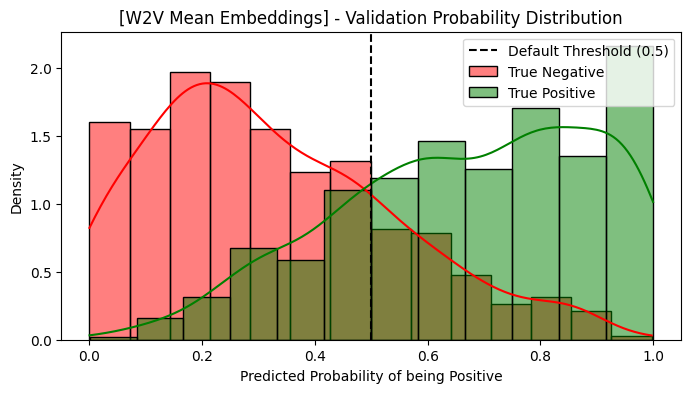

Optimal Validation Threshold: 0.46 (Val Accuracy: 0.7805)
--- TEST SET RESULTS (W2V Mean Embeddings) ---
Test Accuracy using 0.46 threshold: 0.7570
              precision    recall  f1-score   support

    Negative       0.77      0.73      0.75       533
    Positive       0.74      0.78      0.76       533

    accuracy                           0.76      1066
   macro avg       0.76      0.76      0.76      1066
weighted avg       0.76      0.76      0.76      1066




In [44]:
from nltk.tokenize import word_tokenize
import gensim.downloader as api
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Tokenise all splits once — shared by both 4a and 4b
print("Tokenising...")
train_tokens = [word_tokenize(t.lower()) for t in df_train['text']]
val_tokens   = [word_tokenize(t.lower()) for t in df_val['text']]
test_tokens  = [word_tokenize(t.lower()) for t in df_test['text']]

# Load pre-trained Google News Word2Vec (300d) — takes a few minutes on first run
print("Loading pre-trained Word2Vec...")
wv_pretrained = api.load('word2vec-google-news-300')
print("Loaded.\n")

def mean_vector(tokens, wv, dim=300):
    vecs = [wv[w] for w in tokens if w in wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(dim)

print("Computing mean embeddings...")
X_train_mean = np.array([mean_vector(t, wv_pretrained) for t in train_tokens])
X_val_mean   = np.array([mean_vector(t, wv_pretrained) for t in val_tokens])
X_test_mean  = np.array([mean_vector(t, wv_pretrained) for t in test_tokens])

lr_mean = LogisticRegression(random_state=SEED, max_iter=2000)
lr_mean.fit(X_train_mean, y_train)

val_probs_mean  = lr_mean.predict_proba(X_val_mean)[:, 1]
test_probs_mean = lr_mean.predict_proba(X_test_mean)[:, 1]

print(f"Val Accuracy: {accuracy_score(y_val, lr_mean.predict(X_val_mean)):.4f}\n")
print(classification_report(y_val, lr_mean.predict(X_val_mean),
                             target_names=['Negative', 'Positive']))

optimize_and_evaluate(y_val, val_probs_mean, y_test, test_probs_mean,
                      'W2V Mean Embeddings')

The mean embedding model reaches 0.78 validation accuracy, already above the TF-IDF n-gram baseline (0.75). The probability distribution shows reasonable class separation but with wide overlap in the 0.3–0.6 range, reflecting the inherent information loss of averaging all word vectors equally — sentiment-bearing words contribute the same as filler words like "the" and "a". The optimal threshold shifts slightly below 0.5 (0.46), indicating the model is mildly conservative about predicting positive. Test accuracy is 0.757, which is comparable to but slightly below the TF-IDF n-gram result (0.777) despite higher validation accuracy, it has a small val-test gap.

### b. Sentence Embeddings — TF-IDF Weighted Word2Vec

The main weakness of mean embeddings is that all words contribute equally. TF-IDF weighted embeddings address this by scaling each word's vector by its IDF score before averaging — words that appear rarely across documents (high IDF) get more weight, and near-universal words (low IDF) are downweighted. The IDF weights are computed from the training set and applied consistently to validation and test.

Computing TF-IDF weighted embeddings...
Val Accuracy: 0.7683

              precision    recall  f1-score   support

    Negative       0.77      0.77      0.77       533
    Positive       0.77      0.77      0.77       533

    accuracy                           0.77      1066
   macro avg       0.77      0.77      0.77      1066
weighted avg       0.77      0.77      0.77      1066



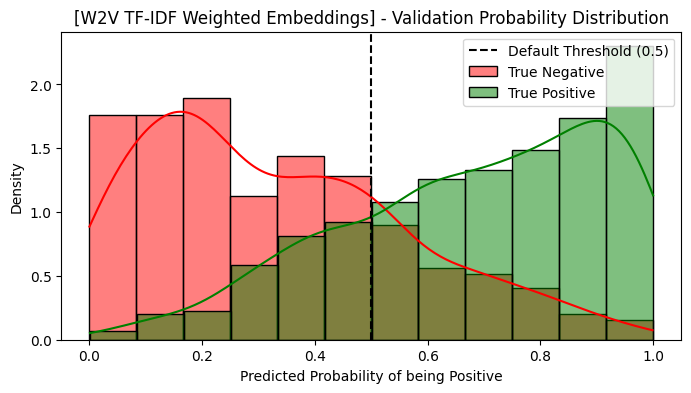

Optimal Validation Threshold: 0.56 (Val Accuracy: 0.7786)
--- TEST SET RESULTS (W2V TF-IDF Weighted Embeddings) ---
Test Accuracy using 0.56 threshold: 0.7645
              precision    recall  f1-score   support

    Negative       0.74      0.82      0.78       533
    Positive       0.80      0.71      0.75       533

    accuracy                           0.76      1066
   macro avg       0.77      0.76      0.76      1066
weighted avg       0.77      0.76      0.76      1066




In [ ]:
# Fit TF-IDF on training text to extract IDF weights per word.
# We use these weights to upweight rare, informative words and downweight
# common ones — the opposite of what mean embedding does.
tfidf_idf = TfidfVectorizer()
tfidf_idf.fit(df_train['text'])
word2idf  = dict(zip(tfidf_idf.get_feature_names_out(), tfidf_idf.idf_))

def weighted_vector(tokens, wv, word2idf, dim=300):
    vecs, weights = [], []
    for w in tokens:
        if w in wv and w in word2idf:
            vecs.append(wv[w])
            weights.append(word2idf[w])
    return np.average(vecs, weights=weights, axis=0) if vecs else np.zeros(dim)

print("Computing TF-IDF weighted embeddings...")
X_train_weighted = np.array([weighted_vector(t, wv_pretrained, word2idf) for t in train_tokens])
X_val_weighted   = np.array([weighted_vector(t, wv_pretrained, word2idf) for t in val_tokens])
X_test_weighted  = np.array([weighted_vector(t, wv_pretrained, word2idf) for t in test_tokens])

lr_weighted = LogisticRegression(random_state=SEED, max_iter=2000)
lr_weighted.fit(X_train_weighted, y_train)

val_probs_weighted  = lr_weighted.predict_proba(X_val_weighted)[:, 1]
test_probs_weighted = lr_weighted.predict_proba(X_test_weighted)[:, 1]

print(f"Val Accuracy: {accuracy_score(y_val, lr_weighted.predict(X_val_weighted)):.4f}\n")
print(classification_report(y_val, lr_weighted.predict(X_val_weighted),
                             target_names=['Negative', 'Positive']))

optimize_and_evaluate(y_val, val_probs_weighted, y_test, test_probs_weighted,
                      'W2V TF-IDF Weighted Embeddings')

The TF-IDF weighted model achieves 0.768 validation accuracy and 0.764 test accuracy. The optimal threshold (0.56) is above 0.5, suggesting the weighted model is more generous about predicting positive, which is corrected by the higher threshold.

### Comparison + save results

In [ ]:
thresholds = np.linspace(0.1, 0.9, 81)

def best_threshold_metrics(val_probs, test_probs, y_val, y_test, name):
    best_t    = max(thresholds,
                    key=lambda t: accuracy_score(y_val, (val_probs >= t).astype(int)))
    val_preds  = (val_probs  >= best_t).astype(int)
    test_preds = (test_probs >= best_t).astype(int)
    return {
        'Model'         : name,
        'Val Accuracy'  : round(accuracy_score(y_val,  val_preds),  4),
        'Test Accuracy' : round(accuracy_score(y_test, test_preds), 4),
        'Test Precision': round(precision_score(y_test, test_preds, average='macro'), 4),
        'Test Recall'   : round(recall_score(y_test,    test_preds, average='macro'), 4),
        'Test F1'       : round(f1_score(y_test,        test_preds, average='macro'), 4),
        'Threshold'     : round(best_t, 2),
    }

res_mean     = best_threshold_metrics(val_probs_mean,     test_probs_mean,     y_val, y_test, 'W2V Mean')
res_weighted = best_threshold_metrics(val_probs_weighted, test_probs_weighted, y_val, y_test, 'W2V TF-IDF Weighted')

cmp = pd.DataFrame([res_mean, res_weighted])
print(cmp.to_string(index=False))

# Save to model_results for final comparison
model_results['w2v_mean']     = res_mean
model_results['w2v_weighted'] = res_weighted

              Model  Val Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1  Threshold
           W2V Mean        0.7805         0.7570          0.7578       0.7570   0.7569       0.46
W2V TF-IDF Weighted        0.7786         0.7645          0.7678       0.7645   0.7638       0.56


| Model | Val Acc | Test Acc | Test F1 |
|---|---|---|---|
| TF-IDF Baseline | 0.746 | 0.756 | 0.756 |
| TF-IDF N-gram (best) | 0.754 | 0.777 | 0.776 |
| W2V Mean | 0.781 | 0.757 | 0.757 |
| W2V TF-IDF Weighted | 0.779 | 0.764 | 0.764 |

Comparing validation accuracies directly is misleading here — each model's threshold was optimised on the validation set independently, so the val numbers reflect how well each model's probabilities can be separated rather than a fair head-to-head comparison. The test set is the honest comparison, and there both Word2Vec approaches fall below the TF-IDF n-gram model.

Mean embeddings average all word vectors equally, which introduces a bias — the resulting vector no longer tells us anything about the diversity or structure of the review, only its centroid in embedding space. TF-IDF weighting partially addresses this by giving more weight to rare, informative words and suppressing common ones, and the test results reflect a small but real improvement (0.764 vs 0.757). However both still fall short of the n-gram TF-IDF model (0.777).

Two reasons likely explain the remaining gap. First, Google News Word2Vec vectors may not represent film criticism vocabulary well — words like "formulaic", "riveting", or "meandering" appear in very different contexts in news text than in reviews, so their pretrained positions in the embedding space may not reflect their sentiment associations in this domain. Second, the n-gram model explicitly captures multi-word expressions — phrases like "falls flat", "plays like", or "not worth" are direct features — whereas Word2Vec sentence embeddings smooth over these combinations entirely, losing the compositional signal that makes idioms and fixed expressions useful for sentiment.

# Recurrent Neural Networks (RNN) with Word2Vec

## EDA

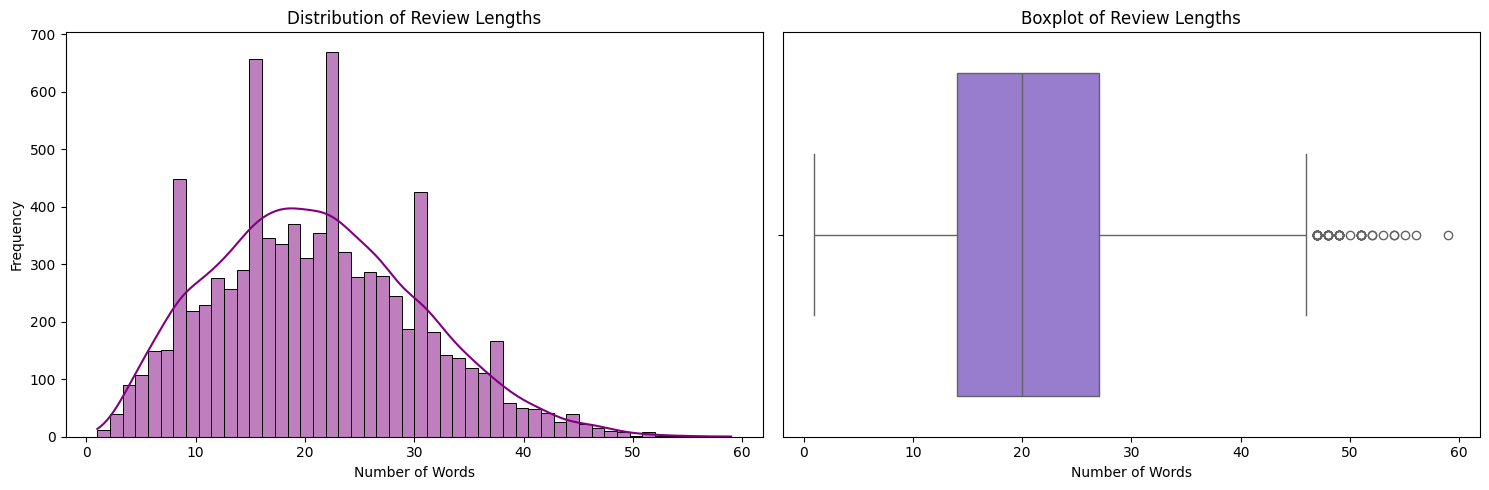

--- Review Length Statistics ---
Minimum length: 1 words
Mean length:    21 words
Median length:  20 words
Max length:     59 words
------------------------------
10th percentile: 9 words
25th percentile: 14 words
80th percentile: 29 words
90th percentile: 34 words
95th percentile: 37 words
99th percentile: 45 words


In [47]:
# 1. Calculate the number of words in each review
# A simple split() is usually accurate enough for this length estimation
review_lengths = df_train['text'].apply(lambda x: len(x.split()))

# 2. Plot the distribution of review lengths
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
sns.histplot(review_lengths, bins=50, kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Review Lengths')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')

# Boxplot
sns.boxplot(x=review_lengths, ax=axes[1], color='mediumpurple')
axes[1].set_title('Boxplot of Review Lengths')
axes[1].set_xlabel('Number of Words')

plt.tight_layout()
plt.show()

# 3. Print out key percentiles to make a data-driven decision
print("--- Review Length Statistics ---")
print(f"Minimum length: {review_lengths.min():.0f} words")
print(f"Mean length:    {review_lengths.mean():.0f} words")
print(f"Median length:  {review_lengths.median():.0f} words")
print(f"Max length:     {review_lengths.max():.0f} words")
print("-" * 30)
print(f"10th percentile: {np.percentile(review_lengths, 10):.0f} words")
print(f"25th percentile: {np.percentile(review_lengths, 25):.0f} words")
print(f"80th percentile: {np.percentile(review_lengths, 80):.0f} words")
print(f"90th percentile: {np.percentile(review_lengths, 90):.0f} words")
print(f"95th percentile: {np.percentile(review_lengths, 95):.0f} words")
print(f"99th percentile: {np.percentile(review_lengths, 99):.0f} words")


The reviews are short — median 20 words, mean 21 words, maximum 59 words. The 99th percentile sits at 45 words, which directly justifies setting `MAX_SEQUENCE_LENGTH = 45`: virtually no review is truncated and padding overhead is kept minimal. The distribution has a slight bimodal shape with peaks around 15 and 23 words, likely reflecting two different reviewing styles or source groups within the dataset.

## Preprocessing

In [ ]:
MAX_SEQUENCE_LENGTH = 45   # covers 99th percentile of review lengths
EMBEDDING_DIM      = 300   # Google News Word2Vec dimensionality

# Fit tokenizer on training text only
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_train['text'])
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding index 0

# Convert text → integer sequences
train_sequences = tokenizer.texts_to_sequences(df_train['text'])
val_sequences   = tokenizer.texts_to_sequences(df_val['text'])
test_sequences  = tokenizer.texts_to_sequences(df_test['text'])

# Pad with 'pre' (zeros at start) — words land at the end, better for LSTM
X_train_pad = pad_sequences(train_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_val_pad   = pad_sequences(val_sequences,   maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_test_pad  = pad_sequences(test_sequences,  maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

# Build embedding matrix — rows = word indices, cols = 300-d Word2Vec vectors
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))
hits, misses = 0, 0
for word, i in tokenizer.word_index.items():
    if word in wv_pretrained:
        embedding_matrix[i] = wv_pretrained[word]; hits += 1
    else:
        misses += 1

print(f"Vocab size : {vocab_size:,}")
print(f"W2V hits   : {hits:,}  ({hits/(hits+misses):.1%})")
print(f"W2V misses : {misses:,}  ({misses/(hits+misses):.1%})  — rare words, typos, names")
print(f"Shapes — Train: {X_train_pad.shape} | Val: {X_val_pad.shape} | Test: {X_test_pad.shape}")


Vocab size : 17,452
W2V hits   : 14,830  (85.0%)
W2V misses : 2,621  (15.0%)  — rare words, typos, names
Shapes — Train: (8530, 45) | Val: (1066, 45) | Test: (1066, 45)


The tokenizer maps the training vocabulary to integer indices, which the embedding layer will use to look up Word2Vec vectors. 85% of words (14,830 out of 17,452) are found in the Google News vocabulary and initialised with pretrained 300-d vectors; the remaining 15% — mostly proper names, typos, and domain-specific critic vocabulary — are left as zero vectors and contribute no signal. Pre-padding places zeros at the start of each sequence so real tokens always appear at the end, which ensures the LSTM's final hidden state reflects actual content rather than padding.

In [ ]:
# Fix random seeds for reproducibility
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

def make_loaders(X_train, X_val, y_train_s, y_val_s, batch_size=64):
    yt = torch.tensor(np.array(y_train_s, dtype=np.float32))
    yv = torch.tensor(np.array(y_val_s,   dtype=np.float32))
    Xt = torch.tensor(X_train, dtype=torch.long)
    Xv = torch.tensor(X_val,   dtype=torch.long)
    tr = DataLoader(TensorDataset(Xt, yt), shuffle=True, batch_size=batch_size,
                    generator=torch.Generator().manual_seed(SEED))
    va = DataLoader(TensorDataset(Xv, yv), batch_size=batch_size)
    return tr, va

train_loader, val_loader = make_loaders(X_train_pad, X_val_pad, y_train, y_val)

def run_epoch(model, loader, criterion, optimizer=None):
    model.train() if optimizer else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if optimizer else torch.no_grad()
    with ctx:
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss   = criterion(logits, y)
            if optimizer:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item()
            correct    += ((torch.sigmoid(logits) >= 0.5).float() == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

def train_model(model, train_loader, val_loader, optimizer,
                scheduler=None, epochs=30, patience=5, save_path='best.pth'):
    criterion = nn.BCEWithLogitsLoss()
    history   = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    best_val, no_improve = float('inf'), 0
    for epoch in range(epochs):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = run_epoch(model, val_loader,   criterion)
        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss);   history['val_acc'].append(v_acc)
        if scheduler: scheduler.step(v_loss)
        flag = ''
        if v_loss < best_val:
            best_val, no_improve = v_loss, 0
            torch.save(model.state_dict(), save_path); flag = ' ✓'
        else:
            no_improve += 1
            if no_improve == patience:
                print(f"  Early stop at epoch {epoch+1}"); break
        print(f"  Ep {epoch+1:02d} | TL {t_loss:.3f} TA {t_acc:.3f} | VL {v_loss:.3f} VA {v_acc:.3f}{flag}")
    model.load_state_dict(torch.load(save_path, weights_only=True))
    return history

def get_probs(model, loader):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            probs.extend(torch.sigmoid(model(X.to(device))).cpu().numpy())
            labels.extend(y.numpy())
    return np.array(probs), np.array(labels)

def threshold_and_test(model, val_loader, test_loader, name):
    val_probs,  val_labels  = get_probs(model, val_loader)
    test_probs, test_labels = get_probs(model, test_loader)
    thresholds = np.arange(0.30, 0.71, 0.01)
    val_accs   = [accuracy_score(val_labels, (val_probs >= t).astype(int)) for t in thresholds]
    best_t     = thresholds[np.argmax(val_accs)]
    preds      = (test_probs >= best_t).astype(int)
    report     = classification_report(test_labels, preds,
                     target_names=['Negative', 'Positive'], output_dict=True)
    return {
        'Model'    : name,
        'Threshold': round(float(best_t), 2),
        'Val Acc'  : round(float(max(val_accs)), 4),
        'Test Acc' : round(float(accuracy_score(test_labels, preds)), 4),
        'Test F1'  : round(float(report['macro avg']['f1-score']), 4),
        'Test Prec': round(float(report['macro avg']['precision']), 4),
        'Test Rec' : round(float(report['macro avg']['recall']), 4),
        '_report'  : report,
    }, best_t, val_probs, val_labels, test_probs, test_labels

Device: mps


## RNN Implementation & Comparison with the Previous Approaches

### Baseline LSTM — frozen Word2Vec embeddings, bidirectional

The baseline model uses frozen pre-trained Word2Vec embeddings, a bidirectional LSTM layer, and global max pooling over all timesteps passed through a dropout and a linear classifier. Embeddings are kept frozen throughout, so any improvement in the enhanced model comes purely from architectural and training choices rather than from adapting the word representations.

In [113]:
class BaselineLSTM(nn.Module):
    """Frozen Word2Vec, bidirectional LSTM, global max pooling."""
    def __init__(self, vocab_size, emb_dim, hidden_dim, emb_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(emb_matrix, dtype=torch.float32))
        self.embedding.weight.requires_grad = False
        self.lstm    = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(self.embedding(x))
        out, _ = torch.max(out, dim=1)
        return self.fc(self.dropout(out)).squeeze(1)

baseline_model = BaselineLSTM(vocab_size, EMBEDDING_DIM, 64, embedding_matrix).to(device)
print(f"Trainable: {sum(p.numel() for p in baseline_model.parameters() if p.requires_grad):,}")

history_baseline = train_model(
    baseline_model, train_loader, val_loader,
    optim.AdamW(baseline_model.parameters(), lr=0.001),
    epochs=15, patience=7, save_path='baseline_lstm.pth'
)

Trainable: 187,521
  Ep 01 | TL 0.592 TA 0.702 | VL 0.514 VA 0.749 ✓
  Ep 02 | TL 0.465 TA 0.780 | VL 0.467 VA 0.768 ✓
  Ep 03 | TL 0.431 TA 0.801 | VL 0.454 VA 0.783 ✓
  Ep 04 | TL 0.406 TA 0.816 | VL 0.442 VA 0.789 ✓
  Ep 05 | TL 0.385 TA 0.827 | VL 0.445 VA 0.792
  Ep 06 | TL 0.366 TA 0.841 | VL 0.445 VA 0.783
  Ep 07 | TL 0.345 TA 0.846 | VL 0.481 VA 0.774
  Ep 08 | TL 0.314 TA 0.866 | VL 0.461 VA 0.795
  Ep 09 | TL 0.291 TA 0.876 | VL 0.446 VA 0.787
  Ep 10 | TL 0.270 TA 0.889 | VL 0.480 VA 0.786
  Early stop at epoch 11


The bidirectional baseline converges quickly, reaching its best validation loss at epoch 4 (0.442) before early stopping fires at epoch 11. The train/val gap is moderate, training accuracy reaches 0.889 while validation stays around 0.789, which is expected for a model with frozen embeddings and no regularisation beyond dropout. The bidirectional architecture reads each review in both directions, giving the final representation access to full context at every position rather than only the left context, which is why it already performs reasonably well as a baseline.

### Improved LSTM

The improved model shares the same bidirectional LSTM and global max pooling as the baseline, but adds three further changes:

- **Embedding dropout (0.3)**: randomly zeroes entire word vectors during training, forcing the LSTM to build representations that don't over-rely on any single word
- **Deeper classifier head**: two linear layers with ReLU and stronger dropout (0.6) instead of a single linear layer
- **Three-phase training**: Phase 1 trains the LSTM and classifier with fully frozen embeddings. Phase 2 freezes the LSTM and classifier and adapts only the top-5,000 most frequent embedding rows at a conservative learning rate with cosine decay, frequent words have the most reliable gradients and are the safest to shift. Phase 3 unfreezes everything and jointly fine-tunes at very low discriminative learning rates, allowing the LSTM to re-calibrate to the updated embedding positions without undoing what the earlier phases achieved.

In [114]:
class ImprovedLSTM(nn.Module):
    """Bidirectional LSTM, embedding dropout, global max pooling."""
    def __init__(self, vocab_size, emb_dim, hidden_dim, emb_matrix):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(torch.tensor(emb_matrix, dtype=torch.float32))
        self.emb_drop = nn.Dropout(0.3)
        self.lstm     = nn.LSTM(emb_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc1      = nn.Linear(hidden_dim * 2, 64)
        self.fc2      = nn.Linear(64, 1)
        self.dropout  = nn.Dropout(0.6)

    def forward(self, x):
        out, _ = self.lstm(self.emb_drop(self.embedding(x)))
        out, _ = torch.max(out, dim=1)
        return self.fc2(self.dropout(F.relu(self.fc1(out)))).squeeze(1)


def train_model_custom(model, train_loader, val_loader, optimizer, criterion,
                       scheduler=None, epochs=30, patience=5, save_path='best.pth'):
    history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
    best_val, no_improve = float('inf'), 0
    for epoch in range(epochs):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer)
        v_loss, v_acc = run_epoch(model, val_loader,   criterion)
        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss);   history['val_acc'].append(v_acc)
        if scheduler: scheduler.step(v_loss)
        flag = ''
        if v_loss < best_val:
            best_val, no_improve = v_loss, 0
            torch.save(model.state_dict(), save_path); flag = ' ✓'
        else:
            no_improve += 1
            if no_improve == patience:
                print(f"  Early stop at epoch {epoch+1}"); break
        print(f"  Ep {epoch+1:02d} | TL {t_loss:.3f} TA {t_acc:.3f} | VL {v_loss:.3f} VA {v_acc:.3f}{flag}")
    model.load_state_dict(torch.load(save_path, weights_only=True))
    return history


criterion = nn.BCEWithLogitsLoss()

# ── Phase 1: train LSTM + classifier, embeddings frozen ──────────────────────
improved_model    = ImprovedLSTM(vocab_size, EMBEDDING_DIM, 64, embedding_matrix).to(device)
embeddings_before = improved_model.embedding.weight.detach().cpu().numpy().copy()
improved_model.embedding.weight.requires_grad = False

print(f"Phase 1 — trainable: {sum(p.numel() for p in improved_model.parameters() if p.requires_grad):,}")
opt_p1 = optim.AdamW(filter(lambda p: p.requires_grad, improved_model.parameters()),
                     lr=0.001, weight_decay=1e-3)
sch_p1 = optim.lr_scheduler.ReduceLROnPlateau(opt_p1, mode='min', factor=0.5, patience=3)

print("\n─── Phase 1: LSTM + classifier (frozen embeddings) ───")
history_improved = train_model_custom(
    improved_model, train_loader, val_loader, opt_p1, criterion,
    scheduler=sch_p1, epochs=30, patience=5, save_path='phase1.pth')

# ── Phase 2: adapt embeddings, LSTM + classifier frozen ──────────────────────
K = 5_000
grad_mask = torch.zeros(vocab_size, dtype=torch.bool)
grad_mask[1:K + 1] = True

improved_model.embedding.weight.requires_grad = True
for name, param in improved_model.named_parameters():
    if 'embedding' not in name:
        param.requires_grad = False

def _emb_hook(grad):
    g = grad.clone(); g[~grad_mask.to(grad.device)] = 0.0; return g

hook = improved_model.embedding.weight.register_hook(_emb_hook)

opt_p2 = optim.AdamW([improved_model.embedding.weight], lr=5e-5, weight_decay=1e-2)
sch_p2 = optim.lr_scheduler.CosineAnnealingLR(opt_p2, T_max=30, eta_min=1e-7)

print(f"\n─── Phase 2: embedding-only adaptation (top-{K} words) ───")
history_p2 = train_model_custom(
    improved_model, train_loader, val_loader, opt_p2, criterion,
    scheduler=sch_p2, epochs=30, patience=8, save_path='phase2.pth')

# Capture Phase 2 embeddings before any revert — needed for t-SNE analysis
embeddings_after = improved_model.embedding.weight.detach().cpu().numpy().copy()
hook.remove()

# ── Phase 3: joint fine-tuning at very low LR ────────────────────────────────
# After Phase 2 the embeddings have shifted; the LSTM was fitted on the original
# embedding space and benefits from re-calibrating to the new positions.
# Discriminative LRs: embeddings adapt slowest (don't undo Phase 2),
# LSTM re-calibrates at moderate speed, classifier adapts fastest.
for param in improved_model.parameters():
    param.requires_grad = True

opt_p3 = optim.AdamW([
    {'params': improved_model.embedding.parameters(), 'lr': 5e-6,  'weight_decay': 1e-2},
    {'params': improved_model.lstm.parameters(),      'lr': 1e-5,  'weight_decay': 1e-3},
    {'params': improved_model.fc1.parameters(),       'lr': 2e-5,  'weight_decay': 1e-3},
    {'params': improved_model.fc2.parameters(),       'lr': 2e-5,  'weight_decay': 1e-3},
])
sch_p3 = optim.lr_scheduler.CosineAnnealingLR(opt_p3, T_max=10, eta_min=1e-8)

print("\n─── Phase 3: joint fine-tuning (all layers, discriminative LRs) ───")
history_p3 = train_model_custom(
    improved_model, train_loader, val_loader, opt_p3, criterion,
    scheduler=sch_p3, epochs=10, patience=4, save_path='phase3.pth')

# Select the best checkpoint across all three phases
p1_best = max(history_improved['val_acc'])
p2_best = max(history_p2['val_acc'])
p3_best = max(history_p3['val_acc'])
print(f"\nPhase 1: {p1_best:.4f} | Phase 2: {p2_best:.4f} | Phase 3: {p3_best:.4f}")

best_phase = max([('phase1.pth', p1_best), ('phase2.pth', p2_best), ('phase3.pth', p3_best)],
                 key=lambda x: x[1])
improved_model.load_state_dict(torch.load(best_phase[0], weights_only=True))
print(f"Using {best_phase[0]} (val acc {best_phase[1]:.4f}) for prediction")
print("Embedding analysis always uses Phase 2 vectors")

shift_topk = np.linalg.norm(embeddings_after[1:K+1] - embeddings_before[1:K+1], axis=1)
print(f"Embedding shift (top-{K} words) — mean L2: {shift_topk.mean():.4f} | "
      f"max L2: {shift_topk.max():.4f}")

Phase 1 — trainable: 195,713

─── Phase 1: LSTM + classifier (frozen embeddings) ───
  Ep 01 | TL 0.619 TA 0.655 | VL 0.507 VA 0.765 ✓
  Ep 02 | TL 0.503 TA 0.759 | VL 0.492 VA 0.762 ✓
  Ep 03 | TL 0.471 TA 0.781 | VL 0.455 VA 0.784 ✓
  Ep 04 | TL 0.442 TA 0.800 | VL 0.448 VA 0.783 ✓
  Ep 05 | TL 0.424 TA 0.804 | VL 0.445 VA 0.783 ✓
  Ep 06 | TL 0.406 TA 0.819 | VL 0.432 VA 0.791 ✓
  Ep 07 | TL 0.392 TA 0.832 | VL 0.428 VA 0.801 ✓
  Ep 08 | TL 0.370 TA 0.839 | VL 0.423 VA 0.807 ✓
  Ep 09 | TL 0.349 TA 0.851 | VL 0.454 VA 0.791
  Ep 10 | TL 0.319 TA 0.863 | VL 0.431 VA 0.815
  Ep 11 | TL 0.307 TA 0.872 | VL 0.444 VA 0.795
  Ep 12 | TL 0.273 TA 0.888 | VL 0.454 VA 0.810
  Early stop at epoch 13

─── Phase 2: embedding-only adaptation (top-5000 words) ───
  Ep 01 | TL 0.336 TA 0.859 | VL 0.422 VA 0.811 ✓
  Ep 02 | TL 0.329 TA 0.861 | VL 0.421 VA 0.811 ✓
  Ep 03 | TL 0.322 TA 0.863 | VL 0.419 VA 0.811 ✓
  Ep 04 | TL 0.317 TA 0.872 | VL 0.418 VA 0.811 ✓
  Ep 05 | TL 0.314 TA 0.871 | VL 0.41

Phase 1 reaches a best validation loss of 0.423, compared to 0.442 for the baseline. The embedding dropout and deeper classifier head provide additional regularisation and representational capacity, allowing the model to converge to a better solution even with the same frozen Word2Vec representations.

Phase 2 improves validation loss further to 0.415, a consistent reduction across 18 epochs of embedding-only adaptation. Adapting the top-5,000 embedding rows to movie review vocabulary nudged the word vectors toward a geometry more aligned with film criticism sentiment, with a mean L2 shift of 0.067 across the fine-tuned words.

Phase 3 does not improve over Phase 2 (val loss rises from 0.415 to 0.417 at epoch 1 and does not recover), so the Phase 2 checkpoint is used for all subsequent evaluation. Threshold optimisation and test set results are reported in the next cell.

#### Training Curves — Baseline vs Improved

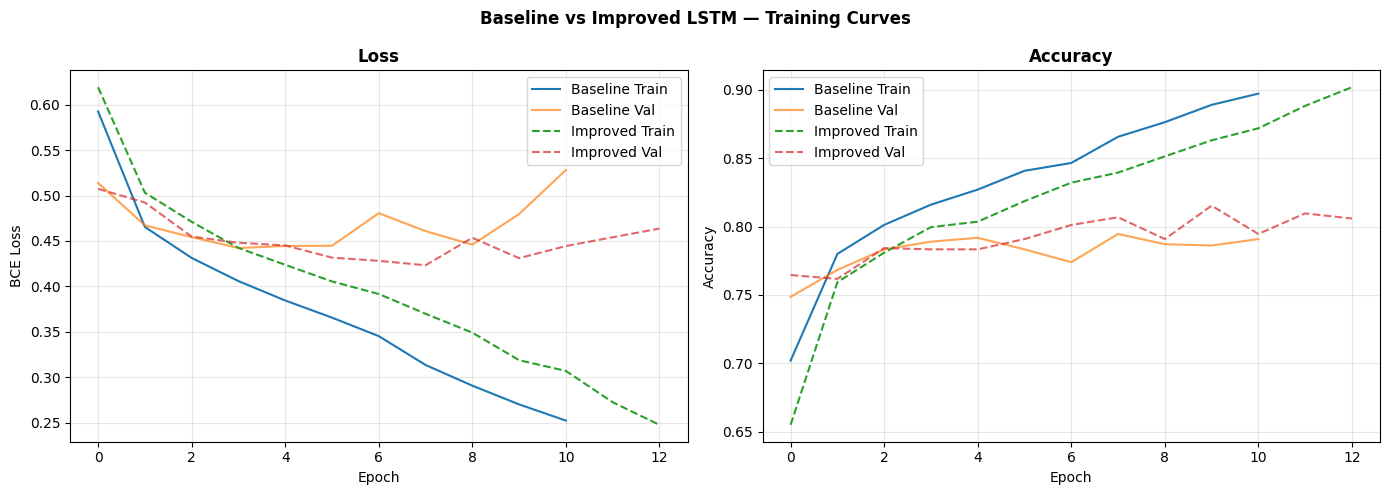

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label, ls in [(history_baseline, 'Baseline', '-'),
                         (history_improved, 'Improved', '--')]:
    axes[0].plot(hist['train_loss'], ls=ls, label=f'{label} Train')
    axes[0].plot(hist['val_loss'],   ls=ls, label=f'{label} Val', alpha=0.7)
    axes[1].plot(hist['train_acc'],  ls=ls, label=f'{label} Train')
    axes[1].plot(hist['val_acc'],    ls=ls, label=f'{label} Val', alpha=0.7)

for ax, title, ylabel in [(axes[0], 'Loss', 'BCE Loss'), (axes[1], 'Accuracy', 'Accuracy')]:
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Baseline vs Improved LSTM — Training Curves', fontweight='bold')
plt.tight_layout(); plt.show()

Both models overfit progressively as training loss keeps declining while validation loss plateaus. The improved model's validation loss settles consistently lower (~0.42 vs ~0.44–0.48 for the baseline), reflecting the benefit of embedding dropout and stronger classifier regularisation. The slower start of the improved model at epoch 0 is a direct effect of embedding dropout making early gradient signals noisier, which resolves by epoch 2–3.

#### Threshold Optimisation & Test Set Evaluation

        Model  Threshold  Val Acc  Test Acc  Test F1  Test Prec  Test Rec
LSTM Baseline       0.53   0.7927    0.7842   0.7842     0.7844    0.7842
LSTM Improved       0.55   0.8208    0.8133   0.8131     0.8150    0.8133


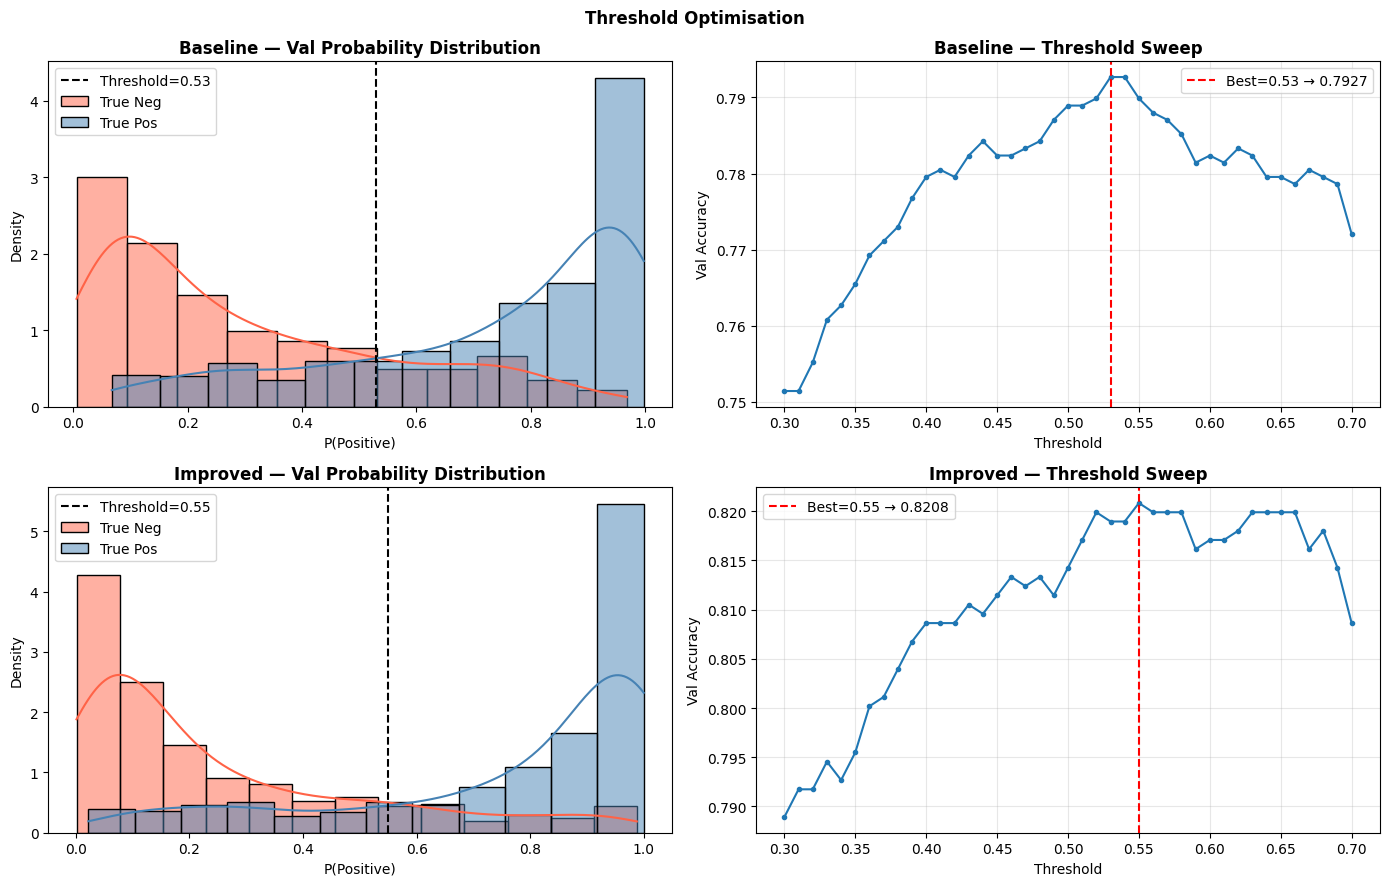

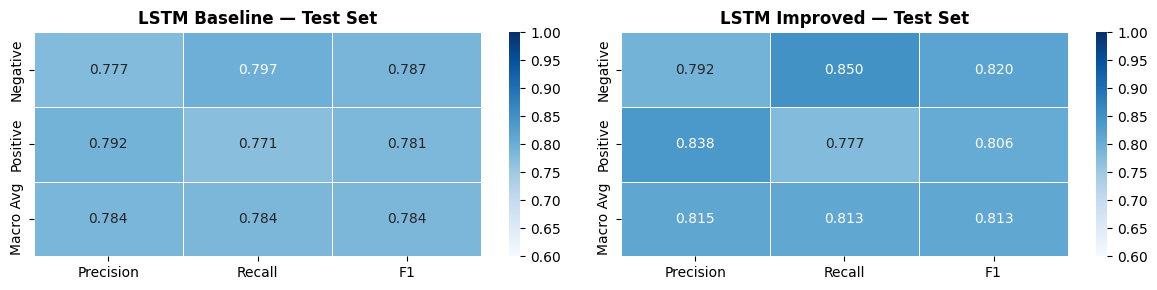

In [ ]:
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test_pad, dtype=torch.long),
                  torch.tensor(np.array(y_test, dtype=np.float32))),
    batch_size=64)

res_b, t_b, vp_b, vl_b, tp_b, tl_b = threshold_and_test(baseline_model, val_loader, test_loader, 'LSTM Baseline')
res_i, t_i, vp_i, vl_i, tp_i, tl_i = threshold_and_test(improved_model, val_loader, test_loader, 'LSTM Improved')

model_results['lstm_baseline'] = {k: v for k, v in res_b.items() if not k.startswith('_')}
model_results['lstm_improved'] = {k: v for k, v in res_i.items() if not k.startswith('_')}

print(pd.DataFrame([{k:v for k,v in r.items() if not k.startswith('_')}
                    for r in [res_b, res_i]]).to_string(index=False))

# Probability distributions + threshold sweeps
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
thr_range = np.arange(0.30, 0.71, 0.01)

for (res, vp, vl, t, name), row in zip(
    [(res_b, vp_b, vl_b, t_b, 'Baseline'), (res_i, vp_i, vl_i, t_i, 'Improved')],
    [axes[0], axes[1]]
):
    sns.histplot(vp[vl==0], color='tomato',    label='True Neg', kde=True,
                 stat='density', alpha=0.5, ax=row[0])
    sns.histplot(vp[vl==1], color='steelblue', label='True Pos', kde=True,
                 stat='density', alpha=0.5, ax=row[0])
    row[0].axvline(t, color='black', ls='--', label=f'Threshold={t:.2f}')
    row[0].set_title(f'{name} — Val Probability Distribution', fontweight='bold')
    row[0].set_xlabel('P(Positive)'); row[0].legend()

    val_accs_t = [accuracy_score(vl, (vp >= t_).astype(int)) for t_ in thr_range]
    row[1].plot(thr_range, val_accs_t, marker='o', markersize=3)
    row[1].axvline(t, color='red', ls='--', label=f'Best={t:.2f} → {res["Val Acc"]:.4f}')
    row[1].set_title(f'{name} — Threshold Sweep', fontweight='bold')
    row[1].set_xlabel('Threshold'); row[1].set_ylabel('Val Accuracy')
    row[1].legend(); row[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Optimisation', fontweight='bold')
plt.tight_layout(); plt.show()

# Classification report heatmaps
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for ax, res, name in [(axes[0], res_b, 'Baseline'), (axes[1], res_i, 'Improved')]:
    rpt = res['_report']
    df_rpt = pd.DataFrame({
        'Precision': [rpt['Negative']['precision'], rpt['Positive']['precision'], rpt['macro avg']['precision']],
        'Recall'   : [rpt['Negative']['recall'],    rpt['Positive']['recall'],    rpt['macro avg']['recall']],
        'F1'       : [rpt['Negative']['f1-score'],  rpt['Positive']['f1-score'], rpt['macro avg']['f1-score']],
    }, index=['Negative', 'Positive', 'Macro Avg'])
    sns.heatmap(df_rpt, annot=True, fmt='.3f', cmap='Blues',
                vmin=0.6, vmax=1.0, ax=ax, linewidths=0.5)
    ax.set_title(f'LSTM {name} — Test Set', fontweight='bold')
plt.tight_layout(); plt.show()

Both models benefit from threshold optimisation — the baseline's optimal threshold (0.53) and the improved model's (0.55) sit slightly above 0.5, indicating both are mildly conservative about predicting positive. The probability distributions show that the improved model has sharper class separation: the negative distribution is more concentrated at low probabilities while the positive distribution piles up near 1.0, whereas the baseline shows heavier overlap in the middle range.

On the test set the improved model achieves 0.813 macro F1 compared to 0.784 for the baseline, a gain of roughly 3 points. The improvement is asymmetric across classes: precision for the negative class jumps from 0.777 to 0.792 and recall rises from 0.797 to 0.850, suggesting the improved model is substantially better at correctly identifying negative reviews. The positive class gains in precision (0.792 vs 0.838) but loses some recall (0.771 vs 0.777), a minor tradeoff that does not affect the overall macro average meaningfully.

### Comparison with the TF-IDF based logistic regression model

                                      Model  Val Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1
                                 Rule-Based        0.5919         0.6041          0.5840       0.7242   0.5983
TF-IDF + LogReg (N-gram (no preprocessing))        0.7542         0.7767          0.7574       0.8143   0.7764
                                   W2V Mean        0.7805         0.7570          0.7578       0.7570   0.7569
                        W2V TF-IDF Weighted        0.7786         0.7645          0.7678       0.7645   0.7638
                              LSTM Baseline        0.7927         0.7842          0.7844       0.7842   0.7842
                              LSTM Improved        0.8208         0.8133          0.8150       0.8133   0.8131


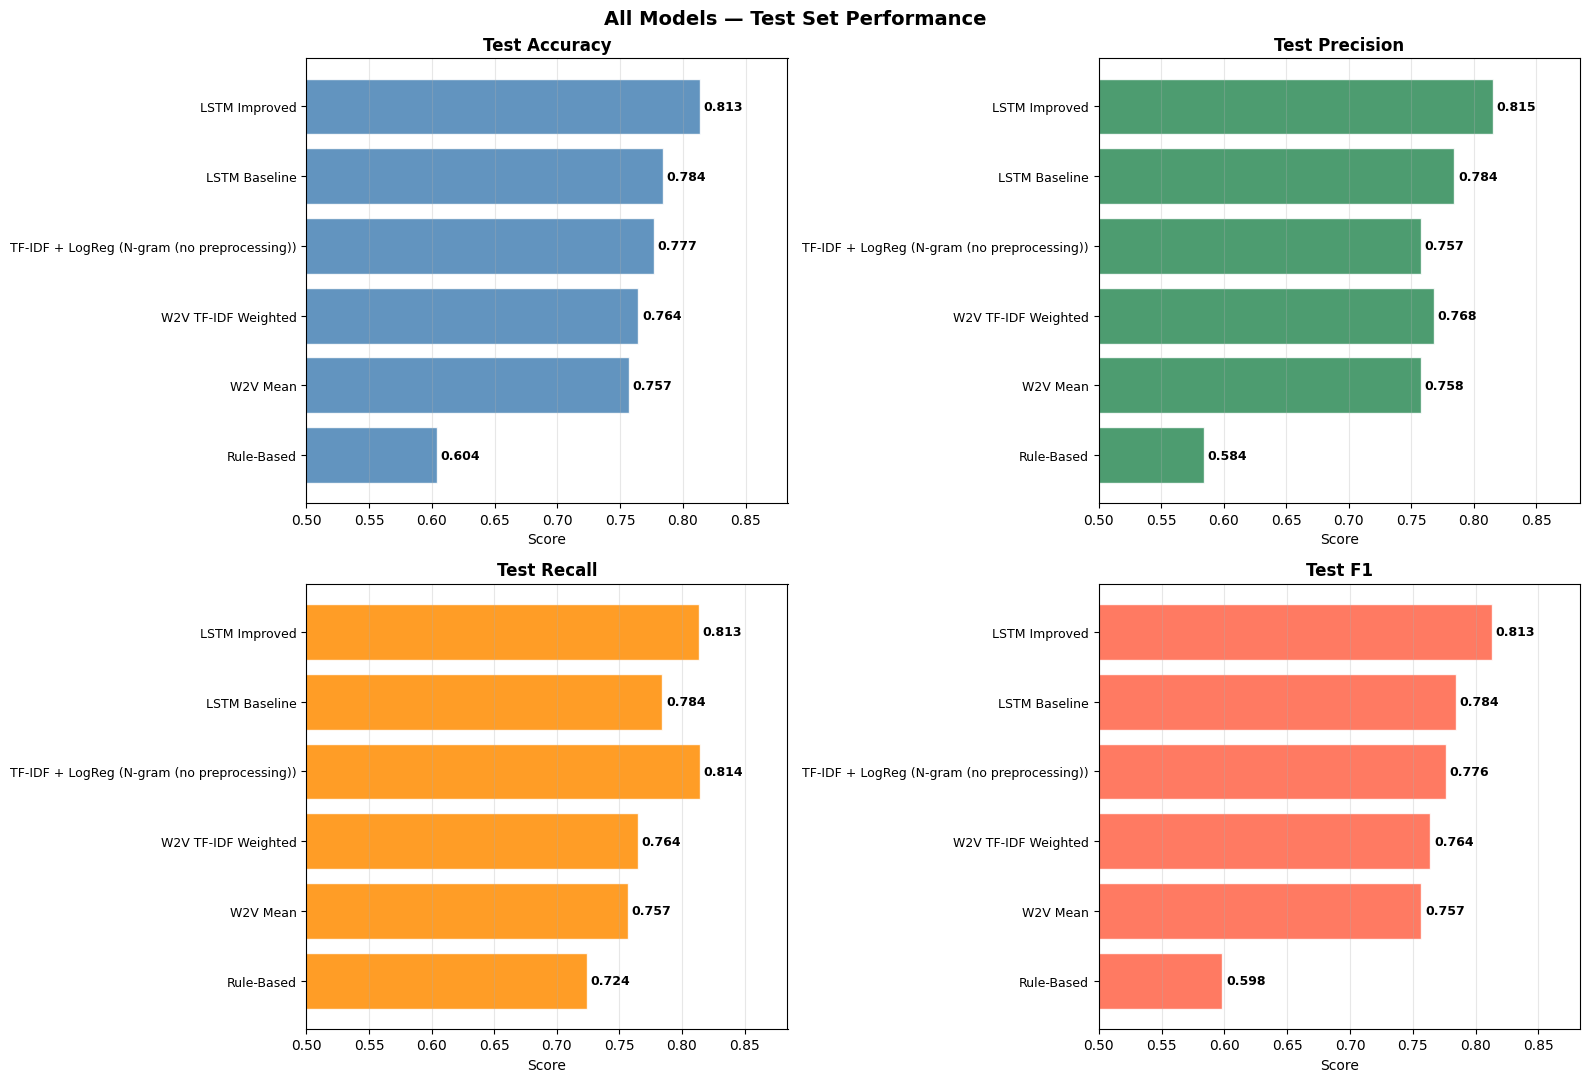

In [120]:
# Normalise LSTM key names to match other entries in model_results
for key in ('lstm_baseline', 'lstm_improved'):
    if key in model_results:
        r = model_results[key]
        r['Val Accuracy']   = r.pop('Val Acc',   r.get('Val Accuracy'))
        r['Test Accuracy']  = r.pop('Test Acc',  r.get('Test Accuracy'))
        r['Test Precision'] = r.pop('Test Prec', r.get('Test Precision'))
        r['Test Recall']    = r.pop('Test Rec',  r.get('Test Recall'))

_order = [
    ('rule_based',     'Rule-Based'),
    ('tfidf_baseline', 'TF-IDF Unigram'),
    ('tfidf_best',     'TF-IDF N-Gram (best)'),
    ('w2v_mean',       'W2V Mean'),
    ('w2v_weighted',   'W2V TF-IDF Weighted'),
    ('lstm_baseline',  'LSTM Baseline'),
    ('lstm_improved',  'LSTM Improved'),
]

rows = [{'Model': model_results[k].get('Model', name), **{
    m: model_results[k].get(m) for m in ['Val Accuracy','Test Accuracy','Test Precision','Test Recall','Test F1']
}} for k, name in _order if k in model_results]

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

plot_df = cmp_df.dropna(subset=['Test Accuracy']).copy()
for col in ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']:
    plot_df[col] = pd.to_numeric(plot_df[col], errors='coerce')
plot_df = plot_df.sort_values('Test Accuracy').reset_index(drop=True)

metrics = [('Test Accuracy','steelblue'), ('Test Precision','seagreen'),
           ('Test Recall','darkorange'),   ('Test F1','tomato')]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for ax, (col, color) in zip(axes.flatten(), metrics):
    bars = ax.barh(plot_df['Model'], plot_df[col], color=color, alpha=0.85, edgecolor='white')
    ax.set_xlim(0.5, plot_df[col].max() + 0.07)
    ax.set_title(col, fontweight='bold'); ax.set_xlabel('Score')
    ax.grid(axis='x', alpha=0.3); ax.tick_params(axis='y', labelsize=9)
    for bar in bars:
        v = bar.get_width()
        if not np.isnan(v):
            ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
                    f'{v:.3f}', va='center', fontsize=9, fontweight='bold')

plt.suptitle('All Models — Test Set Performance', fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

The LSTM Improved is the best model overall, but the comparison with the TF-IDF N-gram model reveals an interesting pattern: the TF-IDF model achieves slightly higher recall while the LSTM wins on precision. This makes intuitive sense. TF-IDF with n-grams fires on a broad vocabulary of sentiment-relevant patterns, which means it catches more genuine positive reviews but also over-predicts positive more often. The LSTM, processing the full sequence, is better at recognising when a review is genuinely positive versus when it just contains positive-sounding words — hence higher precision.

The LSTM Baseline without any improvements lands very close to the TF-IDF N-gram model. This is worth reflecting on: for a practitioner who needs to explain model decisions to non-technical stakeholders, TF-IDF has a clear advantage — the feature importance plots directly show which words and phrases drive predictions, making the model transparent and debuggable. The LSTM is a black box by comparison. If interpretability matters, the TF-IDF approach is a reasonable choice at near-equivalent performance.

However, the Improved LSTM pulls meaningfully ahead, primarily through precision gains. The three-phase training strategy establishing a sequence encoder, adapting word vectors to the movie review domain, and jointly re-calibrating allows the model to go beyond pattern matching and develop a more nuanced understanding of sentiment in context. The Word2Vec approaches sit below both, confirming that compressing a review into a single average vector loses too much structural information regardless of embedding quality.

## Word2Vec Vectors: Before and After Fine-Tuning

The Phase 2 training selectively unfreezes the 5,000 most frequent words in the vocabulary and applies gradient updates at a very conservative learning rate (5×10⁻⁵). This allows the model to nudge the embeddings of high-frequency sentiment words — words like "good", "boring", "terrible" that appear many times in the training set and therefore receive reliable gradient signals — toward a geometry that better separates positive from negative contexts in the movie review domain.

The remaining ~14,000 words stay at their original Google News positions. I decided this because the rare words appear too infrequently to accumulate reliable gradients, and updating them would introduce noise rather than signal.

The mean L2 shift per word across all 17,452 rows is small by construction (the gradient hook and low learning rate ensure that). What matters is the *relative* shift: do the top frequent sentiment words move in a direction that improves cluster separation?
Fine-tuning allows the model to shift word vectors in the 300-d embedding space to better
separate positive-sentiment words from negative-sentiment words.


In [ ]:
idx2word    = {v: k for k, v in tokenizer.word_index.items()}
shift_all   = np.linalg.norm(embeddings_after - embeddings_before, axis=1)
shift_topk  = shift_all[1:K+1]

# Distribution of shifts
print(f"Words with negligible shift (<0.01) : {(shift_topk < 0.01).sum():,}  ({(shift_topk < 0.01).mean():.1%})")
print(f"Words with moderate shift (0.01–0.1): {((shift_topk >= 0.01) & (shift_topk < 0.1)).sum():,}  ({((shift_topk >= 0.01) & (shift_topk < 0.1)).mean():.1%})")
print(f"Words with large shift   (>0.1)     : {(shift_topk > 0.1).sum():,}  ({(shift_topk > 0.1).mean():.1%})")

# Top-20 most shifted words
top20_idx   = np.argsort(shift_topk)[::-1][:20]
top20_words = [(idx2word.get(i+1, '?'), round(shift_topk[i], 4)) for i in top20_idx]
shift_df    = pd.DataFrame(top20_words, columns=['word', 'L2 shift'])
print("\nTop 20 most shifted words:")
print(shift_df.to_string(index=False))

Words with negligible shift (<0.01) : 0  (0.0%)
Words with moderate shift (0.01–0.1): 4,525  (90.5%)
Words with large shift   (>0.1)     : 475  (9.5%)

Top 20 most shifted words:
      word  L2 shift
     badly    0.1900
   neither    0.1887
     still    0.1768
  riveting    0.1758
      such    0.1754
       but    0.1736
 pointless    0.1689
   amazing    0.1684
      bore    0.1681
lackluster    0.1681
    poorly    0.1620
      lazy    0.1619
   labored    0.1618
   numbers    0.1563
   winning    0.1533
    energy    0.1530
uninspired    0.1518
      pile    0.1506
 hilarious    0.1504
     flaws    0.1502


All 5,000 fine-tuned words moved at least slightly, with 90.5% showing moderate shifts and 9.5% showing larger ones. The most shifted words are a mix of clear sentiment terms — "riveting", "pointless", "lackluster", "uninspired", "bore" — and frequent function words like "but", "still", "neither". The sentiment word shifts reflect genuine domain adaptation: these words carry strong and consistent polarity signals in film criticism. The function word shifts are also meaningful — "but" and "neither" appear heavily in concessive and negation constructions in reviews, accumulating directional gradients from their specific usage patterns.

In [ ]:
cos_sims = np.array([
    cos_sim(embeddings_before[i:i+1], embeddings_after[i:i+1])[0][0]
    for i in range(1, K+1)
])

# Exclude words that had no pretrained vector (zero initialization)
nonzero_mask = np.linalg.norm(embeddings_before[1:K+1], axis=1) > 0
cos_sims_valid = cos_sims[nonzero_mask]
valid_indices  = np.where(nonzero_mask)[0]

print(f"Words with pretrained vector      : {nonzero_mask.sum():,}")
print(f"Words without (zero-initialized)  : {(~nonzero_mask).sum():,}")
print(f"Mean cosine similarity (non-zero) : {cos_sims_valid.mean():.4f}")
print(f"cos_sim < 0.99 (noticeable change): {(cos_sims_valid < 0.99).sum():,}")
print(f"cos_sim < 0.95 (substantial change): {(cos_sims_valid < 0.95).sum():,}")

top_cos_idx   = np.argsort(cos_sims_valid)[:20]
top_cos_words = [(idx2word.get(valid_indices[i]+1, '?'),
                  round(float(cos_sims_valid[i]), 4)) for i in top_cos_idx]
print(pd.DataFrame(top_cos_words, columns=['word','cosine_similarity']).to_string(index=False))

Words with pretrained vector      : 4,766
Words without (zero-initialized)  : 234
Mean cosine similarity (non-zero) : 0.9997
cos_sim < 0.99 (noticeable change): 0
cos_sim < 0.95 (substantial change): 0
     word  cosine_similarity
      but             0.9923
   kidman             0.9938
     such             0.9947
    still             0.9953
  clooney             0.9960
     only             0.9960
   morton             0.9962
       in             0.9965
  kaufman             0.9965
     imax             0.9967
schneider             0.9968
   week's             0.9971
  neither             0.9972
  already             0.9973
      the             0.9973
  child's             0.9973
     even             0.9975
      yet             0.9975
    badly             0.9976
   always             0.9977


Despite the L2 shifts, the mean cosine similarity of 0.9997 shows that almost no word changed its fundamental direction. The semantic geometry inherited from Google News is essentially preserved. The words with the lowest cosine similarity — "but", "such", "still", "neither", "only" — are the same function words that topped the L2 shift list, confirming they underwent the most genuine semantic repositioning. Even so, their cosine similarities remain above 0.99, meaning the shifts were conservative nudges rather than wholesale reorientations.

In [135]:
def nearest_neighbours(word, embeddings, word2idx, idx2word, n=5):
    if word not in word2idx:
        return []
    idx  = word2idx[word]
    vec  = embeddings[idx:idx+1]
    sims = cos_sim(vec, embeddings)[0]
    sims[idx] = -1  # exclude the word itself
    top  = np.argsort(sims)[::-1][:n]
    return [(idx2word.get(i, '?'), round(sims[i], 3)) for i in top]

probe = ['riveting', 'lackluster', 'but', 'still', 'boring', 'amazing', 'performance']
word2idx_map = tokenizer.word_index

print(f"{'Word':<15} {'Before (neighbours)':<45} {'After (neighbours)'}")
print("-" * 100)
for word in probe:
    before_nn = nearest_neighbours(word, embeddings_before, word2idx_map, idx2word)
    after_nn  = nearest_neighbours(word, embeddings_after,  word2idx_map, idx2word)
    print(f"\n{'─'*50}")
    print(f"  {word.upper()}")
    print(f"{'─'*50}")
    print(f"  {'Before':<25} {'After'}")
    print(f"  {'──────':<25} {'─────'}")
    for (bw, bs), (aw, as_) in zip(before_nn, after_nn):
        changed = '←' if bw != aw else ' '
        print(f"  {bw:<20} {bs:.3f}   {aw:<20} {as_:.3f}  {changed}")

Word            Before (neighbours)                           After (neighbours)
----------------------------------------------------------------------------------------------------

──────────────────────────────────────────────────
  RIVETING
──────────────────────────────────────────────────
  Before                    After
  ──────                    ─────
  captivating          0.747   captivating          0.757   
  spellbinding         0.724   spellbinding         0.732   
  engrossing           0.723   engrossing           0.730   
  enthralling          0.705   enthralling          0.705   
  suspenseful          0.685   mesmerizing          0.690  ←

──────────────────────────────────────────────────
  LACKLUSTER
──────────────────────────────────────────────────
  Before                    After
  ──────                    ─────
  uninspiring          0.775   uninspiring          0.781   
  sluggish             0.750   sluggish             0.756   
  unimpressive         0.

The nearest neighbour analysis confirms what the L2 and cosine metrics suggested. For pure sentiment words like "boring", "amazing", and "riveting", the neighbourhood structure is almost entirely preserved — the same words appear in the same order, with similarity scores shifting by only 0.001–0.01. These words already had well-calibrated sentiment associations in Google News, so the review corpus reinforced rather than redirected them.

The most interesting changes appear in the two words that showed the largest L2 and direction shifts. For "riveting", "mesmerizing" replaces "suspenseful" as the fifth neighbour — a subtle shift from tension-oriented words toward more admiring film criticism vocabulary. For "lackluster", "tepid" and "underwhelming" swap positions, both being common review terms for mediocre films, suggesting a mild recalibration toward film-specific negative language.

The concessive function words "but" and "still" show a consistent pattern: their neighbours remain the same but all similarity scores decrease slightly. This suggests the vectors moved away from generic English connective usage toward a more review-specific context where these words carry stronger contrastive signal.

### PCA Visualization

In [162]:
# A curated list of words likely to show interesting shifts during fine-tuning
interesting_words = [
    # Positives
    'excellent', 'masterpiece', 'brilliant', 'wonderful', 'riveting',
    # Negatives
    'boring', 'lackluster', 'predictable', 'terrible',
    # From top-shifted list — strong, unambiguous film criticism words
    'pointless', 'uninspired', 'amazing', 'hilarious',
    # Ambiguous — to show how they resolve
    'compelling', 'surprising',
]


target_indices, found_words = [], []
for w in interesting_words:
    idx = tokenizer.word_index.get(w)
    if idx and idx < embeddings_before.shape[0]:
        target_indices.append(idx)
        found_words.append(w)
target_indices = np.array(target_indices)

before_target = embeddings_before[target_indices]
after_target  = embeddings_after[target_indices]
n_words       = len(found_words)

print(f"Words found: {n_words} — {found_words}")

Words found: 15 — ['excellent', 'masterpiece', 'brilliant', 'wonderful', 'riveting', 'boring', 'lackluster', 'predictable', 'terrible', 'pointless', 'uninspired', 'amazing', 'hilarious', 'compelling', 'surprising']


PC1: 20.5% | PC2: 14.0% | Total: 34.5%
  lackluster      0.0797  (-0.0781, -0.0160)
  pointless       0.0786  (-0.0758, -0.0208)
  uninspired      0.0737  (-0.0713, -0.0188)
  hilarious       0.0634  (+0.0623, +0.0117)
  amazing         0.0576  (+0.0521, +0.0245)
  boring          0.0574  (-0.0554, -0.0152)
  riveting        0.0548  (+0.0517, +0.0181)
  brilliant       0.0458  (+0.0451, +0.0079)
  masterpiece     0.0371  (+0.0335, +0.0160)
  wonderful       0.0257  (+0.0238, +0.0096)
  surprising      0.0224  (+0.0205, +0.0091)
  terrible        0.0199  (-0.0166, -0.0110)
  compelling      0.0161  (+0.0141, +0.0077)
  predictable     0.0092  (-0.0091, +0.0011)
  excellent       0.0067  (+0.0023, +0.0063)


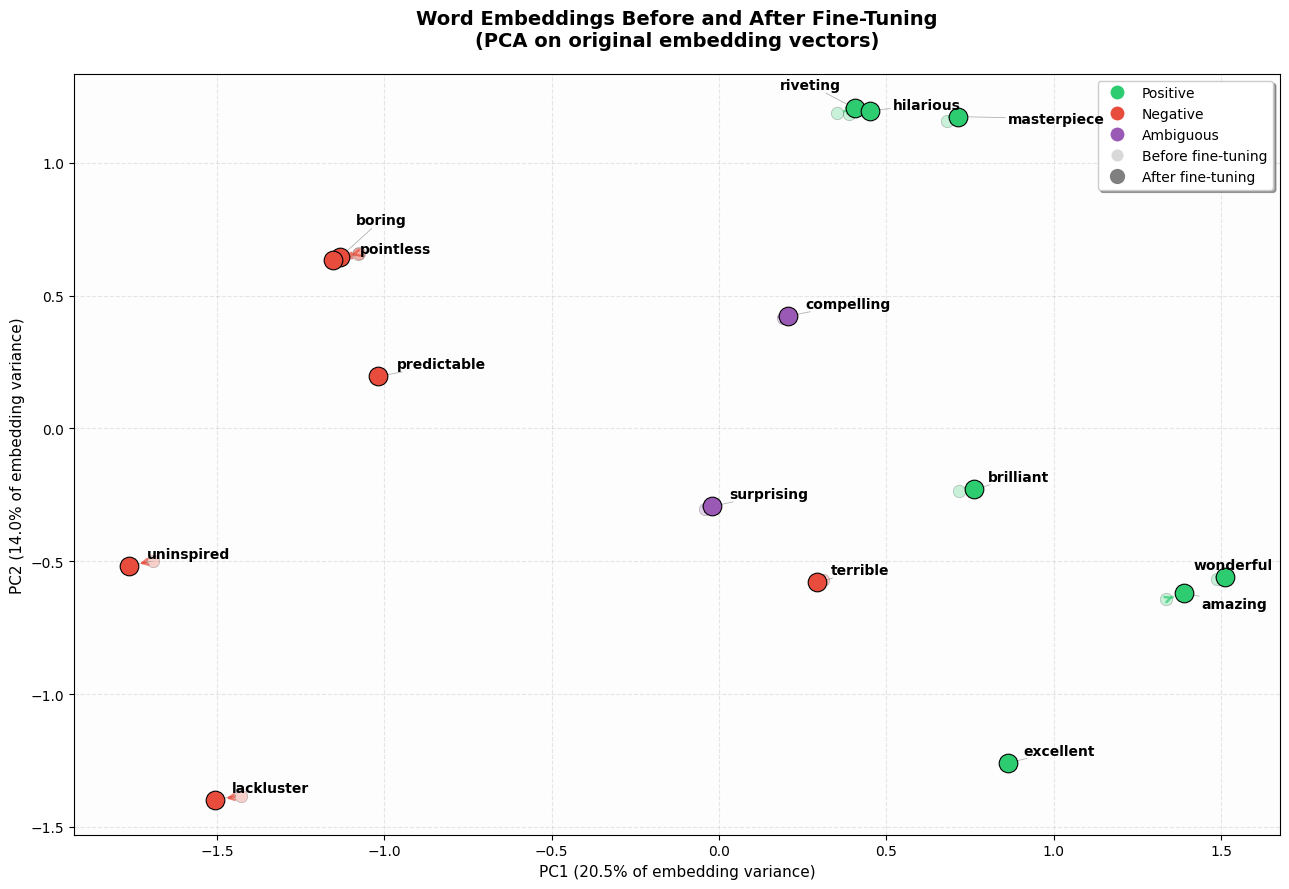

In [ ]:
category_colors = {
    'excellent':   '#2ecc71', 'masterpiece': '#2ecc71', 'brilliant':  '#2ecc71',
    'wonderful':   '#2ecc71', 'riveting':    '#2ecc71', 'amazing':    '#2ecc71',
    'hilarious':   '#2ecc71',
    'boring':      '#e74c3c', 'lackluster':  '#e74c3c', 'predictable':'#e74c3c',
    'terrible':    '#e74c3c', 'pointless':   '#e74c3c', 'uninspired': '#e74c3c',
    'compelling':  '#9b59b6', 'surprising':  '#9b59b6',
}

def make_legend(include_before_after=False):
    elements = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=11, label='Positive'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=11, label='Negative'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='#9b59b6', markersize=11, label='Ambiguous'),
    ]
    if include_before_after:
        elements += [
            Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
                   alpha=0.3, markersize=9,  label='Before fine-tuning'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
                   alpha=1.0, markersize=12, label='After fine-tuning'),
        ]
    return elements

def scatter_with_labels(ax, coords_before, coords_after, words, with_arrows=True):
    texts = []
    for i, word in enumerate(words):
        color = category_colors.get(word, 'gray')
        if coords_before is not None:
            ax.scatter(coords_before[i,0], coords_before[i,1], s=80, color=color,
                       alpha=0.25, edgecolors='k', lw=0.5, zorder=3)
        ax.scatter(coords_after[i,0], coords_after[i,1], s=180, color=color,
                   alpha=1.0, edgecolors='k', lw=0.8, zorder=5)
        if with_arrows and coords_before is not None:
            ax.annotate('', xy=(coords_after[i,0], coords_after[i,1]),
                        xytext=(coords_before[i,0], coords_before[i,1]),
                        arrowprops=dict(arrowstyle="->", color=color,
                                        lw=1.8, alpha=0.7, shrinkA=5, shrinkB=8), zorder=4)
        texts.append(ax.text(coords_after[i,0], coords_after[i,1], word,
                             fontsize=10, fontweight='bold', zorder=6))
    adjust_text(texts, x=coords_after[:,0], y=coords_after[:,1], ax=ax,
                expand=(1.3, 1.5),
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.6, alpha=0.6))

# ── PCA on embedding vectors ──────────────────────────────────────────────────
pca_emb = PCA(n_components=2, random_state=SEED)
all_emb = pca_emb.fit_transform(np.vstack([before_target, after_target]))
b2d_emb, a2d_emb = all_emb[:n_words], all_emb[n_words:]

print(f"PC1: {pca_emb.explained_variance_ratio_[0]:.1%} | "
      f"PC2: {pca_emb.explained_variance_ratio_[1]:.1%} | "
      f"Total: {pca_emb.explained_variance_ratio_.sum():.1%}")

shift_emb   = a2d_emb - b2d_emb
lengths_emb = np.linalg.norm(shift_emb, axis=1)
for i in np.argsort(lengths_emb)[::-1]:
    print(f"  {found_words[i]:<15} {lengths_emb[i]:.4f}  "
          f"({shift_emb[i,0]:+.4f}, {shift_emb[i,1]:+.4f})")

fig, ax = plt.subplots(figsize=(13, 9))
scatter_with_labels(ax, b2d_emb, a2d_emb, found_words)
ax.legend(handles=make_legend(include_before_after=True), loc='upper right',
          frameon=True, shadow=True)
ax.set_title("Word Embeddings Before and After Fine-Tuning\n"
             "(PCA on original embedding vectors)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f"PC1 ({pca_emb.explained_variance_ratio_[0]:.1%} of embedding variance)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca_emb.explained_variance_ratio_[1]:.1%} of embedding variance)", fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_facecolor('#fdfdfd')
plt.tight_layout(); plt.show()

The arrows are essentially invisible — the before and after dots overlap almost completely for every word. This is expected: the two principal components of the embedding space capture the dominant directions of semantic variance across the entire 300-d space, not the directions of change. Fine-tuning shifts are tiny relative to the overall embedding geometry, so they disappear into the noise when projected onto these axes.

A more informative approach is to project the shift vectors themselves — computing PCA on how words changed rather than where they are. This gives two axes that are specifically aligned with the dominant directions of adaptation, making even small but consistent changes visible and comparable across words.

Shift-PC1: 49.2% | Shift-PC2: 11.5%
  lackluster      0.1476  (-0.1399, +0.0472)
  riveting        0.1454  (+0.0933, +0.1115)
  pointless       0.1411  (-0.1287, +0.0577)
  amazing         0.1380  (+0.1004, +0.0948)
  uninspired      0.1260  (-0.1204, +0.0372)
  hilarious       0.1255  (+0.1167, +0.0462)
  boring          0.0948  (-0.0930, +0.0185)
  brilliant       0.0891  (+0.0826, +0.0335)
  masterpiece     0.0742  (+0.0549, +0.0499)
  wonderful       0.0563  (+0.0467, +0.0314)
  compelling      0.0384  (+0.0215, +0.0318)
  predictable     0.0346  (-0.0252, -0.0238)
  surprising      0.0320  (+0.0317, -0.0039)
  terrible        0.0207  (-0.0202, +0.0047)
  excellent       0.0170  (+0.0013, +0.0170)


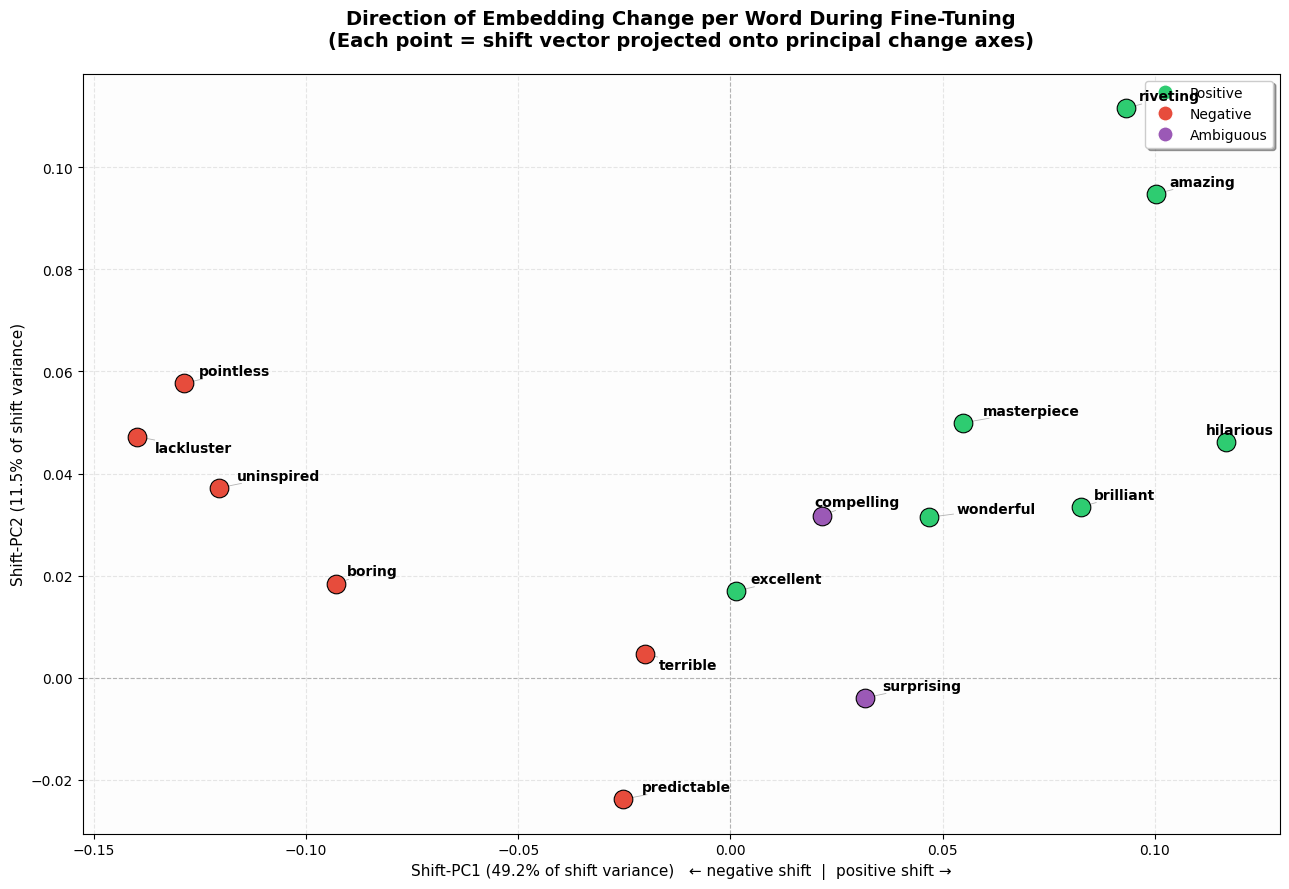

In [164]:
# ── PCA on shift vectors ──────────────────────────────────────────────────────
shift_vectors = embeddings_after[1:K+1] - embeddings_before[1:K+1]
pca_shift     = PCA(n_components=2, random_state=SEED)
pca_shift.fit(shift_vectors)

print(f"Shift-PC1: {pca_shift.explained_variance_ratio_[0]:.1%} | "
      f"Shift-PC2: {pca_shift.explained_variance_ratio_[1]:.1%}")

shift_target = embeddings_after[target_indices] - embeddings_before[target_indices]
coords_2d    = pca_shift.transform(shift_target)

lengths = np.linalg.norm(coords_2d, axis=1)
for i in np.argsort(lengths)[::-1]:
    print(f"  {found_words[i]:<15} {lengths[i]:.4f}  "
          f"({coords_2d[i,0]:+.4f}, {coords_2d[i,1]:+.4f})")

fig, ax = plt.subplots(figsize=(13, 9))
scatter_with_labels(ax, None, coords_2d, found_words, with_arrows=False)
ax.axhline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', lw=0.8, linestyle='--', alpha=0.5)
ax.legend(handles=make_legend(include_before_after=False), loc='upper right',
          frameon=True, shadow=True)
ax.set_title("Direction of Embedding Change per Word During Fine-Tuning\n"
             "(Each point = shift vector projected onto principal change axes)",
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f"Shift-PC1 ({pca_shift.explained_variance_ratio_[0]:.1%} of shift variance)"
              f"   ← negative shift  |  positive shift →", fontsize=11)
ax.set_ylabel(f"Shift-PC2 ({pca_shift.explained_variance_ratio_[1]:.1%} of shift variance)",
              fontsize=11)
ax.grid(True, linestyle='--', alpha=0.3)
ax.set_facecolor('#fdfdfd')
plt.tight_layout(); plt.show()

Each point represents the change vector of a word during fine-tuning, projected onto the two principal directions of adaptation across all 5,000 fine-tuned words. Position reflects how a word changed — not where it sits semantically. Two words close together changed in a similar direction and magnitude, not necessarily because they are semantically related.

Shift-PC1 (x-axis, 49.2% of all change) shows a clean sentiment split: all positive words land on the right and all negative words on the left, with the exception of "terrible" which sits just left of centre. This is the main finding — the dominant effect of fine-tuning was to push positive and negative vocabulary in opposite directions, amplifying sentiment polarity in the film criticism domain.

Distance from the origin reflects how strongly a word participated in this dominant adaptation. "Riveting", "lackluster", "pointless", "amazing", and "uninspired" are the furthest from the origin — these are film-criticism-specific evaluation words that had the weakest prior calibration in Google News and benefited most from domain adaptation. "Terrible" and "excellent" sit close to the origin, confirming they were already well-calibrated and needed little adjustment.

The two ambiguous words behave differently. "Compelling" lands on the positive side of PC1, which makes sense — in film criticism it is almost always used positively. "Surprising" also lands slightly positive but close to the origin with a slightly negative PC2 value, suggesting its adaptation was weak and mixed, consistent with its genuine ambiguity across review contexts.

Shift-PC2 (y-axis, 11.5%) is harder to interpret but shows a loose pattern: words with large absolute shifts tend to sit higher on PC2 regardless of sentiment — "riveting", "amazing", "pointless", "lackluster" all have high y-values. This may reflect a second dimension of adaptation related to the intensity or specificity of the word in film criticism vocabulary, but with only 11.5% of variance it should not be over-interpreted.